# Phát hiện ảnh AI-generated

**Đề tài:** Phân loại ảnh thật / ảnh do AI tạo ra

**Dataset:** CIFAKE

**Mô hình so sánh:**
1. FFT + XGBoost (Classical ML)
2. FFT + SVM (Classical ML)
3. ResNet50 (CNN - Transfer Learning)
4. EfficientNet-B0 (CNN - Compound Scaling)
5. Vision Transformer — ViT-B/16 (Attention-based)
6. Ensemble (ResNet50 + XGBoost weighted average)


## 1. Cài thư viện cần thiết


In [ ]:
!pip install -q kaggle xgboost scikit-learn matplotlib pandas pyarrow \
             torch torchvision timm Pillow seaborn tqdm joblib streamlit pyngrok
# timm: PyTorch Image Models — cung cấp EfficientNet và ViT pretrained


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 52.4 MB/s eta 0:00:00


## 2. Upload kaggle.json



In [ ]:
import os, shutil

try:
    from google.colab import files
except ImportError:
    files = None

if files is None:
    print('Cell upload kaggle.json chỉ chạy trong Google Colab. Nếu chạy local, hãy đặt kaggle.json vào ~/.kaggle/kaggle.json')
else:
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    if 'kaggle.json' in uploaded:
        shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
        os.chmod('/root/.kaggle/kaggle.json', 0o600)
        print('Đã cấu hình Kaggle API')
    else:
        print('Chưa thấy kaggle.json')


Saving kaggle.json to kaggle.json
Đã cấu hình Kaggle API


## 3. Tải dataset CIFAKE


In [ ]:
import os
from pathlib import Path

DATA_DIR = Path('data/raw/cifake')
DATA_DIR.mkdir(parents=True, exist_ok=True)

if not any(DATA_DIR.rglob('*.jpg')):
    import subprocess
    subprocess.run([
        "kaggle", "datasets", "download",
        "-d", "birdy654/cifake-real-and-ai-generated-synthetic-images",
        "-p", "data/raw", "--unzip"
    ], check=True)
    # Đổi tên thư mục về chuẩn train/REAL, train/FAKE, test/REAL, test/FAKE
    import shutil
    for split in ['train','test']:
        for label, src_name in [('REAL','REAL'),('FAKE','FAKE')]:
            src = Path(f'data/raw/{split}/{src_name}')
            dst = DATA_DIR / split / label
            if src.exists() and not dst.exists():
                shutil.move(str(src), str(dst))
    print('Dataset đã sẵn sàng.')
else:
    print('Dataset đã có sẵn.')

# Thống kê
for split in ['train','test']:
    for label in ['REAL','FAKE']:
        d = DATA_DIR / split / label
        n = len(list(d.glob('*'))) if d.exists() else 0
        print(f'  {split}/{label}: {n:,} ảnh')


Dataset đã sẵn sàng.
  train/REAL: 50,000 ảnh
  train/FAKE: 50,000 ảnh
  test/REAL: 10,000 ảnh
  test/FAKE: 10,000 ảnh


## 4. Khám phá dữ liệu


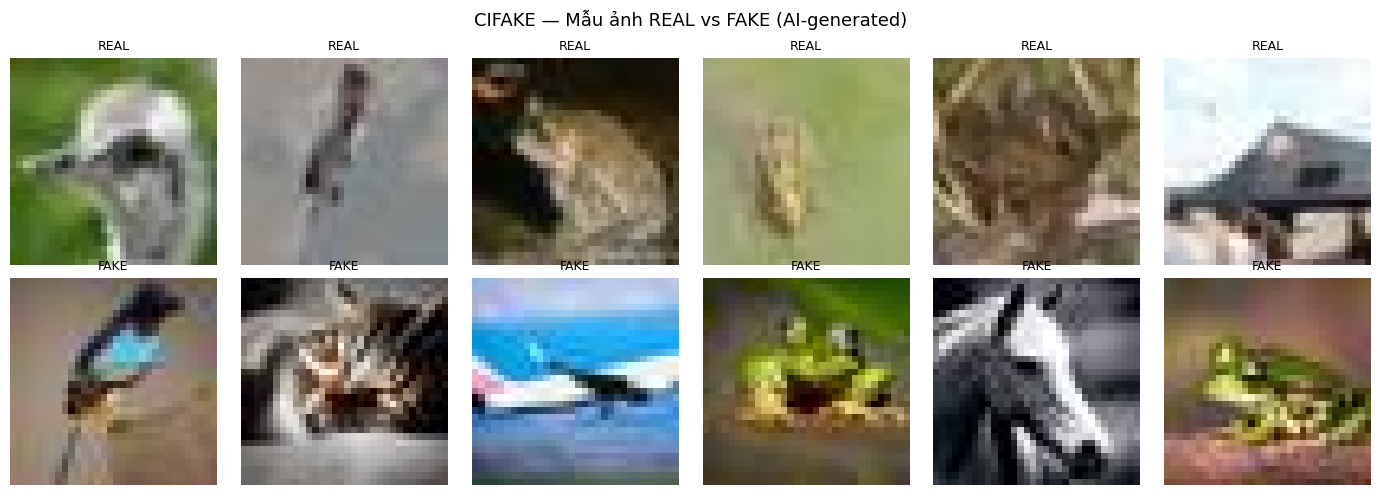

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

root = Path('data/raw/cifake')

# Hiển thị ảnh mẫu
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for row, label in enumerate(['REAL', 'FAKE']):
    imgs = list((root / 'train' / label).glob('*.jpg'))[:6]
    for col in range(6):
        if col < len(imgs):
            axes[row, col].imshow(Image.open(imgs[col]))
            axes[row, col].set_title(label, fontsize=9)
        axes[row, col].axis('off')
plt.suptitle('CIFAKE — Mẫu ảnh REAL vs FAKE (AI-generated)', fontsize=13)
plt.tight_layout()
plt.show()
plt.close()


## 5. Tiền xử lý ảnh


In [ ]:
%%writefile preprocess.py
from pathlib import Path
import json
import numpy as np
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE  = 224
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

TRAIN_TF = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

TEST_TF = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

def get_loaders(data_dir, batch_size=32, num_workers=2):
    train_ds = datasets.ImageFolder(str(Path(data_dir)/'train'), transform=TRAIN_TF)
    test_ds  = datasets.ImageFolder(str(Path(data_dir)/'test'),  transform=TEST_TF)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    print(f'Train: {len(train_ds):,} ảnh | Test: {len(test_ds):,} ảnh')
    print(f'class_to_idx: {train_ds.class_to_idx}  (FAKE=0, REAL=1)')
    return train_loader, test_loader, train_ds.class_to_idx

if __name__ == '__main__':
    get_loaders('data/raw/cifake')
    print('Tiền xử lý OK')


Overwriting preprocess.py


In [ ]:
!python preprocess.py


Train: 100,000 ảnh | Test: 20,000 ảnh
class_to_idx: {'FAKE': 0, 'REAL': 1}  (FAKE=0, REAL=1)
Tiền xử lý OK


## 6. Mô hình 1 — FFT + XGBoost




In [ ]:
%%writefile fft_features.py
import argparse
import json
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

LABEL_MAP = {'REAL': 0, 'FAKE': 1}  # chuẩn chung toàn notebook: 0=REAL, 1=FAKE
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}


def norm_path(p: Path) -> str:
    """Normalize path để các model có thể merge prediction theo đúng ảnh."""
    return str(Path(p).as_posix())


def list_images(folder: Path):
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in {e.lower() for e in IMG_EXTS}],
        key=lambda x: norm_path(x)
    )


def extract_fft(img_path: Path, size: int = 64) -> np.ndarray:
    """Grayscale → resize → 2D FFT → log magnitude → flatten."""
    img = Image.open(img_path).convert('L').resize((size, size))
    arr = np.array(img, dtype=np.float32)
    fft = np.fft.fft2(arr)
    shifted = np.fft.fftshift(fft)
    magnitude = np.log1p(np.abs(shifted))
    return magnitude.flatten()


def build_features(data_dir: Path, split: str, size: int = 64, limit: int = 0):
    rows, labels, paths, records = [], [], [], []

    # Giữ thứ tự label rõ ràng: REAL rồi FAKE. Không dựa vào ImageFolder.
    for label_name in ['REAL', 'FAKE']:
        label_val = LABEL_MAP[label_name]
        folder = data_dir / split / label_name
        imgs = list_images(folder)
        if limit > 0:
            imgs = imgs[:limit]

        for p in tqdm(imgs, desc=f'{split}/{label_name}'):
            path_str = norm_path(p)
            rows.append(extract_fft(p, size))
            labels.append(label_val)
            paths.append(path_str)
            records.append({'filepath': path_str, 'label': label_val, 'label_name': label_name})

    X = np.array(rows, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    return X, y, paths, records


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--data',  default='data/raw/cifake')
    parser.add_argument('--out',   default='data/features')
    parser.add_argument('--size',  type=int, default=64)
    parser.add_argument('--limit', type=int, default=0, help='0=all; nếu >0 thì giới hạn mỗi lớp')
    args = parser.parse_args()

    out = Path(args.out)
    out.mkdir(parents=True, exist_ok=True)
    data = Path(args.data)

    for split in ['train', 'test']:
        X, y, paths, records = build_features(data, split, args.size, args.limit)
        np.save(out / f'fft_{split}_X.npy', X)
        np.save(out / f'fft_{split}_y.npy', y)
        (out / f'fft_{split}_paths.json').write_text(
            json.dumps(paths, indent=2), encoding='utf-8'
        )
        pd.DataFrame(records).to_csv(out / f'fft_{split}_manifest.csv', index=False)
        print(
            f'Saved {split}: X={X.shape}, y={y.shape}, paths={len(paths)} | '
            f'labels REAL={int((y==0).sum())}, FAKE={int((y==1).sum())}'
        )


if __name__ == '__main__':
    main()


Writing fft_features.py


In [ ]:
!pip install -q tqdm
!python fft_features.py --data data/raw/cifake --out data/features --size 64 --limit 0


train/REAL: 100% 50000/50000 [00:33<00:00, 1493.38it/s]
train/FAKE: 100% 50000/50000 [00:31<00:00, 1562.83it/s]
Saved train: X=(100000, 4096), y=(100000,), paths=100000 | labels REAL=50000, FAKE=50000
test/REAL: 100% 10000/10000 [00:09<00:00, 1088.16it/s]
test/FAKE: 100% 10000/10000 [00:06<00:00, 1482.12it/s]
Saved test: X=(20000, 4096), y=(20000,), paths=20000 | labels REAL=10000, FAKE=10000


In [ ]:
%%writefile train_xgboost.py
import argparse
import json
from pathlib import Path

import numpy as np
import torch
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, roc_curve
)

LABEL_NOTE = 'Chuẩn label: 0=REAL, 1=FAKE. probabilities = P(FAKE=AI-generated).'


def save_cm(cm, path, title):
    fig, ax = plt.subplots(figsize=(4,4))
    ax.imshow(cm, cmap='Blues')
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_xticklabels(['REAL','FAKE'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['REAL','FAKE'])
    max_val = cm.max() if cm.size else 0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if max_val and cm[i,j] > max_val/2 else 'black', fontsize=14)
    plt.tight_layout(); plt.savefig(path, dpi=200, bbox_inches='tight'); plt.close()


def load_paths(features_dir: Path, split: str, expected_len: int):
    path_file = features_dir / f'fft_{split}_paths.json'
    if not path_file.exists():
        raise FileNotFoundError(
            f'Thiếu {path_file}. Hãy chạy lại cell fft_features.py trước khi train XGBoost. '
            'Ensemble cần filepath để align labels đúng.'
        )
    paths = json.loads(path_file.read_text(encoding='utf-8'))
    if len(paths) != expected_len:
        raise ValueError(f'{path_file}: có {len(paths)} paths nhưng X/y có {expected_len} mẫu')
    return paths


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--features', default='data/features')
    parser.add_argument('--out',      default='results/xgboost')
    parser.add_argument('--n_estimators', type=int, default=300)
    parser.add_argument('--max_depth',    type=int, default=6)
    args = parser.parse_args()
    out = Path(args.out); out.mkdir(parents=True, exist_ok=True)
    feat = Path(args.features)

    X_tr = np.load(feat/'fft_train_X.npy'); y_tr = np.load(feat/'fft_train_y.npy')
    X_te = np.load(feat/'fft_test_X.npy');  y_te = np.load(feat/'fft_test_y.npy')
    train_paths = load_paths(feat, 'train', len(y_tr))
    test_paths  = load_paths(feat, 'test',  len(y_te))
    print(f'Train: {X_tr.shape}, Test: {X_te.shape}')
    print(f'Test label distribution: REAL={(y_te==0).sum():,}, FAKE={(y_te==1).sum():,}')

    clf = XGBClassifier(
        n_estimators=args.n_estimators, max_depth=args.max_depth,
        learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss',
        tree_method='hist', device='cuda' if torch.cuda.is_available() else 'cpu'
    )
    clf.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=50)
    clf.save_model(str(out/'xgboost_model.json'))

    prob = clf.predict_proba(X_te)[:,1]  # P(FAKE)
    pred = (prob>=0.5).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_te, pred, labels=[0,1])
    auc = float(roc_auc_score(y_te, prob)) if len(np.unique(y_te)) == 2 else float('nan')

    metrics = {
        'model':'FFT-XGBoost',
        'accuracy':float(accuracy_score(y_te,pred)),
        'precision':float(prec),'recall':float(rec),'f1':float(f1),
        'roc_auc':auc,'confusion_matrix':cm.tolist(),'n_test':int(len(y_te)),
        'label_distribution': {'REAL': int((y_te==0).sum()), 'FAKE': int((y_te==1).sum())},
        'label_note': LABEL_NOTE,
        'has_paths': True,
    }
    print(json.dumps(metrics,indent=2))

    save_cm(cm, out/'confusion_matrix.png','Confusion Matrix - FFT-XGBoost')
    if len(np.unique(y_te)) == 2:
        fpr,tpr,_=roc_curve(y_te,prob)
        plt.figure(); plt.plot(fpr,tpr,label=f'AUC={auc:.4f}'); plt.plot([0,1],[0,1],'k--')
        plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC - FFT-XGBoost'); plt.legend()
        plt.savefig(out/'roc_curve.png',dpi=200,bbox_inches='tight'); plt.close()

    payload = {
        'probabilities': prob.tolist(),
        'labels': y_te.tolist(),
        'paths': test_paths,
        'label_note': LABEL_NOTE,
    }
    (out/'xgboost_probs.json').write_text(json.dumps(payload, indent=2), encoding='utf-8')
    (out/'metrics.json').write_text(json.dumps(metrics,indent=2), encoding='utf-8')
    print(f'Saved to {out}')


if __name__ == '__main__':
    main()


Writing train_xgboost.py


In [ ]:
!python train_xgboost.py --features data/features --out results/xgboost


Train: (100000, 4096), Test: (20000, 4096)
Test label distribution: REAL=10,000, FAKE=10,000
[0]	validation_0-logloss:0.66682
[50]	validation_0-logloss:0.38407
[100]	validation_0-logloss:0.34230
[150]	validation_0-logloss:0.32432
[200]	validation_0-logloss:0.31402
[250]	validation_0-logloss:0.30669
[299]	validation_0-logloss:0.30205
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [17:42:24] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
{
  "model": "FFT-XGBoost",
  "accuracy": 0.87365,
  "precision": 0.8736562811620865,
  "recall": 0.87365,
  "

## 6b. Mô hình 1b — FFT + SVM




In [ ]:
%%writefile train_svm.py
import argparse, json
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, roc_curve
)

def save_cm(cm, path, title):
    fig, ax = plt.subplots(figsize=(4,4))
    ax.imshow(cm, cmap='Oranges')
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_xticklabels(['REAL','FAKE'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['REAL','FAKE'])
    for i in range(2):
        for j in range(2):
            ax.text(j,i,str(cm[i,j]),ha='center',va='center',
                    color='white' if cm[i,j]>cm.max()/2 else 'black', fontsize=14)
    plt.tight_layout(); plt.savefig(path, dpi=200, bbox_inches='tight'); plt.close()

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--features', default='data/features')
    parser.add_argument('--out',      default='results/svm')
    parser.add_argument('--kernel',   default='rbf', choices=['rbf','linear','poly'])
    parser.add_argument('--C',        type=float, default=1.0)
    parser.add_argument('--gamma',    default='scale')
    parser.add_argument('--limit',    type=int, default=8000,
                         help='Giới hạn số mẫu train (SVM rất chậm với >10K mẫu, O(n^2~n^3))')
    args = parser.parse_args()

    out  = Path(args.out); out.mkdir(parents=True, exist_ok=True)
    feat = Path(args.features)

    X_tr = np.load(feat/'fft_train_X.npy'); y_tr = np.load(feat/'fft_train_y.npy')
    X_te = np.load(feat/'fft_test_X.npy');  y_te = np.load(feat/'fft_test_y.npy')

    # ── Giới hạn dữ liệu train (SVM phức tạp O(n^2) đến O(n^3) theo số mẫu) ──
    if args.limit > 0 and args.limit < len(X_tr):
        rng = np.random.RandomState(42)
        idx_0 = np.where(y_tr == 0)[0]
        idx_1 = np.where(y_tr == 1)[0]
        n_per_class = args.limit // 2
        sel = np.concatenate([
            rng.choice(idx_0, min(n_per_class, len(idx_0)), replace=False),
            rng.choice(idx_1, min(n_per_class, len(idx_1)), replace=False),
        ])
        rng.shuffle(sel)
        X_tr, y_tr = X_tr[sel], y_tr[sel]

    print(f'Train: {X_tr.shape}, Test: {X_te.shape}')

    # ── Chuẩn hóa đặc trưng
    # SVM dựa trên khoảng cách Euclidean trong kernel, nên scale ảnh hưởng lớn
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    clf = SVC(
        kernel=args.kernel, C=args.C, gamma=args.gamma,
        probability=True,   # cần để lấy predict_proba cho ROC-AUC
        random_state=42,
    )
    print(f'Training SVM (kernel={args.kernel}, C={args.C}, gamma={args.gamma})...')
    clf.fit(X_tr_scaled, y_tr)
    print(f'Số support vectors: {clf.n_support_} (REAL, FAKE)')

    prob = clf.predict_proba(X_te_scaled)[:, 1]
    pred = (prob >= 0.5).astype(int)

    prec, rec, f1, _ = precision_recall_fscore_support(y_te, pred, average='weighted', zero_division=0)
    cm  = confusion_matrix(y_te, pred, labels=[0,1])
    auc = float(roc_auc_score(y_te, prob))

    metrics = {
        'model': 'SVM (RBF)', 'kernel': args.kernel, 'C': args.C,
        'n_support_vectors': [int(n) for n in clf.n_support_],
        'n_train_used': int(len(X_tr)),
        'accuracy': float(accuracy_score(y_te, pred)),
        'precision': float(prec), 'recall': float(rec), 'f1': float(f1),
        'roc_auc': auc, 'confusion_matrix': cm.tolist(), 'n_test': int(len(y_te)),
    }
    print(json.dumps(metrics, indent=2))

    save_cm(cm, out/'confusion_matrix.png', 'Confusion Matrix - SVM (RBF)')
    fpr, tpr, _ = roc_curve(y_te, prob)
    plt.figure(); plt.plot(fpr, tpr, color='darkorange', label=f'AUC={auc:.4f}')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC - SVM (RBF)'); plt.legend()
    plt.savefig(out/'roc_curve.png', dpi=200, bbox_inches='tight'); plt.close()

    (out/'svm_probs.json').write_text(
        json.dumps({'probabilities': prob.tolist(), 'labels': y_te.tolist()}, indent=2),
        encoding='utf-8')
    (out/'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')

    import joblib
    joblib.dump({'model': clf, 'scaler': scaler}, out/'svm_model.joblib')
    print(f'Saved to {out}')

if __name__ == '__main__':
    main()


Writing train_svm.py


In [ ]:
!pip install -q joblib
!python train_svm.py \
    --features data/features \
    --out      results/svm \
    --kernel   rbf \
    --C        1.0 \
    --gamma    scale \
    --limit    8000


Train: (8000, 4096), Test: (20000, 4096)
Training SVM (kernel=rbf, C=1.0, gamma=scale)...
Số support vectors: [2448 2385] (REAL, FAKE)
{
  "model": "SVM (RBF)",
  "kernel": "rbf",
  "C": 1.0,
  "n_support_vectors": [
    2448,
    2385
  ],
  "n_train_used": 8000,
  "accuracy": 0.82875,
  "precision": 0.8287555263803984,
  "recall": 0.82875,
  "f1": 0.8287492803188504,
  "roc_auc": 0.9058444,
  "confusion_matrix": [
    [
      8267,
      1733
    ],
    [
      1692,
      8308
    ]
  ],
  "n_test": 20000
}
Saved to results/svm


## 7. Mô hình 2 — ResNet50



In [ ]:
%%writefile train_resnet50.py
import argparse
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

LABEL_NOTE = 'Chuẩn label: 0=REAL, 1=FAKE. probabilities = P(FAKE=AI-generated).'


def norm_path(p) -> str:
    return str(Path(p).as_posix())


def get_transforms(img_size=224):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    return train_tf, val_tf


def save_confusion_matrix(cm, out_path, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['REAL', 'FAKE'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['REAL', 'FAKE'])
    plt.colorbar(im, ax=ax)
    max_val = cm.max() if cm.size else 0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if max_val and cm[i, j] > max_val / 2 else 'black', fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close()


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--data',   default='data/raw/cifake')
    parser.add_argument('--out',    default='results/resnet50')
    parser.add_argument('--epochs', type=int, default=3)
    parser.add_argument('--batch',  type=int, default=32)
    parser.add_argument('--lr',     type=float, default=1e-4)
    parser.add_argument('--img_size', type=int, default=224)
    args = parser.parse_args()

    out = Path(args.out)
    out.mkdir(parents=True, exist_ok=True)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')

    train_tf, val_tf = get_transforms(args.img_size)

    train_ds = datasets.ImageFolder(str(Path(args.data) / 'train'), transform=train_tf)
    test_ds  = datasets.ImageFolder(str(Path(args.data) / 'test'),  transform=val_tf)

    # ImageFolder sort alphabetically: FAKE=0, REAL=1 trên CIFAKE.
    # Train vẫn dùng raw class index của ImageFolder.
    # Khi lưu metrics/probability cho toàn notebook, chuẩn hóa lại thành: 0=REAL, 1=FAKE.
    print(f'class_to_idx (raw ImageFolder): {train_ds.class_to_idx}')
    fake_idx = train_ds.class_to_idx.get('FAKE', train_ds.class_to_idx.get('fake'))
    real_idx = train_ds.class_to_idx.get('REAL', train_ds.class_to_idx.get('real'))
    if fake_idx is None or real_idx is None:
        raise ValueError(f'Không tìm thấy class REAL/FAKE trong {train_ds.class_to_idx}')
    remap = {fake_idx: 1, real_idx: 0}
    print(f'Metric label remap: {remap}  (0=REAL, 1=FAKE)')

    train_loader = DataLoader(train_ds, batch_size=args.batch, shuffle=True,  num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=args.batch, shuffle=False, num_workers=2)

    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.5)

    history = {'loss': [], 'acc': []}
    for epoch in range(args.epochs):
        model.train()
        total_loss = correct = total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out_logits = model(imgs)
            loss = criterion(out_logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out_logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
        epoch_loss = total_loss / total
        epoch_acc  = correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        print(f'Epoch {epoch+1}/{args.epochs}  loss={epoch_loss:.4f}  acc={epoch_acc:.4f}')
        scheduler.step()

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(np.array([remap[int(l)] for l in labels], dtype=np.int32))

    all_probs  = np.concatenate(all_probs,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    test_paths = [norm_path(p) for p, _ in test_ds.samples]
    if len(test_paths) != len(all_labels):
        raise ValueError(f'Số test paths ({len(test_paths)}) khác số labels ({len(all_labels)})')

    # Output raw của model theo ImageFolder: col fake_idx = P(FAKE), col real_idx = P(REAL)
    prob_fake = all_probs[:, fake_idx]
    pred = (prob_fake >= 0.5).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, pred, average='weighted', zero_division=0
    )
    cm = confusion_matrix(all_labels, pred, labels=[0, 1])
    roc_auc = float(roc_auc_score(all_labels, prob_fake)) if len(np.unique(all_labels)) == 2 else float('nan')

    metrics = {
        'model': 'ResNet50',
        'epochs': args.epochs,
        'accuracy':  float(accuracy_score(all_labels, pred)),
        'precision': float(precision),
        'recall':    float(recall),
        'f1':        float(f1),
        'roc_auc':   roc_auc,
        'confusion_matrix': cm.tolist(),
        'n_test': int(len(all_labels)),
        'label_distribution': {'REAL': int((all_labels==0).sum()), 'FAKE': int((all_labels==1).sum())},
        'raw_class_to_idx': train_ds.class_to_idx,
        'fake_idx': int(fake_idx),
        'real_idx': int(real_idx),
        'label_note': LABEL_NOTE,
        'has_paths': True,
    }
    print(json.dumps(metrics, indent=2))

    torch.save(model.state_dict(), out / 'resnet50_weights.pth')
    (out / 'history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')
    (out / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
    (out / 'resnet50_probs.json').write_text(json.dumps({
        'probabilities': prob_fake.tolist(),
        'labels': all_labels.tolist(),
        'paths': test_paths,
        'label_note': LABEL_NOTE,
        'raw_class_to_idx': train_ds.class_to_idx,
        'fake_idx': int(fake_idx),
        'real_idx': int(real_idx),
    }, indent=2), encoding='utf-8')

    save_confusion_matrix(cm, out / 'confusion_matrix.png', 'Confusion Matrix - ResNet50')
    if len(np.unique(all_labels)) == 2:
        fpr, tpr, _ = roc_curve(all_labels, prob_fake)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f'AUC={roc_auc:.4f}')
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.title('ROC Curve - ResNet50'); plt.legend()
        plt.tight_layout()
        plt.savefig(out / 'roc_curve.png', dpi=200, bbox_inches='tight')
        plt.close()

    print(f'Saved model + metrics to {out}')


if __name__ == '__main__':
    main()


Writing train_resnet50.py


In [ ]:
!python train_resnet50.py --data data/raw/cifake --out results/resnet50 --epochs 5


Device: cuda
class_to_idx (raw ImageFolder): {'FAKE': 0, 'REAL': 1}
Metric label remap: {0: 1, 1: 0}  (0=REAL, 1=FAKE)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100% 97.8M/97.8M [00:00<00:00, 132MB/s]
Epoch 1/5  loss=0.1372  acc=0.9469
Epoch 2/5  loss=0.0690  acc=0.9741
Epoch 3/5  loss=0.0381  acc=0.9862
Epoch 4/5  loss=0.0186  acc=0.9933
Epoch 5/5  loss=0.0114  acc=0.9961
{
  "model": "ResNet50",
  "epochs": 5,
  "accuracy": 0.98605,
  "precision": 0.9860657922775911,
  "recall": 0.98605,
  "f1": 0.9860498866902045,
  "roc_auc": 0.9990255,
  "confusion_matrix": [
    [
      9832,
      168
    ],
    [
      111,
      9889
    ]
  ],
  "n_test": 20000,
  "label_distribution": {
    "REAL": 10000,
    "FAKE": 10000
  },
  "raw_class_to_idx": {
    "FAKE": 0,
    "REAL": 1
  },
  "fake_idx": 0,
  "real_idx": 1,
  "label_note": "Chu\u1ea9n label: 0=REAL, 1=FAKE. probabilities = P(FAKE=AI-generate

## 8. Mô hình 3 — EfficientNet-B0




In [ ]:
%%writefile train_efficientnet.py
import argparse, json
from pathlib import Path
import numpy as np
import torch, timm
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]; STD = [0.229, 0.224, 0.225]

def get_loaders(data_dir, batch_size):
    tf_train = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2,0.2,0.1),
        transforms.ToTensor(), transforms.Normalize(MEAN,STD)
    ])
    tf_val = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(), transforms.Normalize(MEAN,STD)
    ])
    tr = datasets.ImageFolder(str(Path(data_dir)/'train'), transform=tf_train)
    te = datasets.ImageFolder(str(Path(data_dir)/'test'),  transform=tf_val)
    return (DataLoader(tr,batch_size,shuffle=True,num_workers=2,pin_memory=True),
            DataLoader(te,batch_size,shuffle=False,num_workers=2,pin_memory=True),
            tr.class_to_idx)

def save_cm(cm, path, title):
    fig,ax=plt.subplots(figsize=(4,4)); ax.imshow(cm,cmap='Greens')
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_xticklabels(['REAL','FAKE'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['REAL','FAKE'])
    for i in range(2):
        for j in range(2):
            ax.text(j,i,str(cm[i,j]),ha='center',va='center',
                    color='white' if cm[i,j]>cm.max()/2 else 'black',fontsize=14)
    plt.tight_layout(); plt.savefig(path,dpi=200,bbox_inches='tight'); plt.close()

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--data',   default='data/raw/cifake')
    parser.add_argument('--out',    default='results/efficientnet')
    parser.add_argument('--epochs', type=int, default=5)
    parser.add_argument('--batch',  type=int, default=32)
    parser.add_argument('--lr',     type=float, default=1e-4)
    args = parser.parse_args()

    out = Path(args.out); out.mkdir(parents=True, exist_ok=True)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')

    train_loader, test_loader, c2i = get_loaders(args.data, args.batch)
    fake_idx = c2i.get('FAKE', 0); real_idx = c2i.get('REAL', 1)
    remap = {fake_idx: 1, real_idx: 0}
    print(f'class_to_idx={c2i}  →  remap={remap}')

    # EfficientNet-B0 từ timm
    model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs)

    history = {'loss':[], 'acc':[]}
    for epoch in range(args.epochs):
        model.train()
        total_loss = correct = total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out_logits = model(imgs)
            loss = criterion(out_logits, labels)
            loss.backward(); optimizer.step()
            total_loss += loss.item()*imgs.size(0)
            correct    += (out_logits.argmax(1)==labels).sum().item()
            total      += imgs.size(0)
        scheduler.step()
        ep_loss = total_loss/total; ep_acc = correct/total
        history['loss'].append(ep_loss); history['acc'].append(ep_acc)
        print(f'Epoch {epoch+1}/{args.epochs}  loss={ep_loss:.4f}  acc={ep_acc:.4f}')

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            probs = torch.softmax(model(imgs.to(device)), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(np.array([remap[l.item()] for l in labels]))
    all_probs  = np.concatenate(all_probs,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    prob_fake  = all_probs[:, fake_idx]
    pred = (prob_fake>=0.5).astype(int)

    prec,rec,f1,_ = precision_recall_fscore_support(all_labels,pred,average='weighted',zero_division=0)
    cm  = confusion_matrix(all_labels, pred, labels=[0,1])
    auc = float(roc_auc_score(all_labels, prob_fake))
    metrics = {'model':'EfficientNet-B0','accuracy':float(accuracy_score(all_labels,pred)),
               'precision':float(prec),'recall':float(rec),'f1':float(f1),
               'roc_auc':auc,'confusion_matrix':cm.tolist(),'n_test':int(len(all_labels))}
    print(json.dumps(metrics,indent=2))

    # Curves
    fig,axes=plt.subplots(1,2,figsize=(10,4))
    axes[0].plot(history['loss'],'o-'); axes[0].set_title('Loss'); axes[0].grid(alpha=.4)
    axes[1].plot(history['acc'],'o-',color='green'); axes[1].set_title('Accuracy'); axes[1].grid(alpha=.4)
    plt.suptitle('EfficientNet-B0 Training'); plt.tight_layout()
    plt.savefig(out/'accuracy_curve.png',dpi=200,bbox_inches='tight'); plt.close()
    save_cm(cm, out/'confusion_matrix.png','Confusion Matrix - EfficientNet-B0')
    fpr,tpr,_=roc_curve(all_labels,prob_fake)
    plt.figure(); plt.plot(fpr,tpr,label=f'AUC={auc:.4f}'); plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC - EfficientNet-B0'); plt.legend()
    plt.savefig(out/'roc_curve.png',dpi=200,bbox_inches='tight'); plt.close()

    (out/'efficientnet_probs.json').write_text(
        json.dumps({'probabilities':prob_fake.tolist(),'labels':all_labels.tolist()},indent=2),encoding='utf-8')
    (out/'metrics.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')
    torch.save(model.state_dict(), str(out/'efficientnet_weights.pth'))
    print(f'Saved to {out}')

if __name__ == '__main__': main()


Writing train_efficientnet.py


In [ ]:
!python train_efficientnet.py --data data/raw/cifake --out results/efficientnet --epochs 5


Device: cuda
class_to_idx={'FAKE': 0, 'REAL': 1}  →  remap={0: 1, 1: 0}
model.safetensors: 100% 21.4M/21.4M [00:02<00:00, 10.4MB/s]
Epoch 1/5  loss=0.2337  acc=0.9305
Epoch 2/5  loss=0.0795  acc=0.9704
Epoch 3/5  loss=0.0470  acc=0.9826
Epoch 4/5  loss=0.0236  acc=0.9914
Epoch 5/5  loss=0.0130  acc=0.9954
{
  "model": "EfficientNet-B0",
  "accuracy": 0.98505,
  "precision": 0.9850502376746164,
  "recall": 0.98505,
  "f1": 0.9850499981686247,
  "roc_auc": 0.998911725,
  "confusion_matrix": [
    [
      9847,
      153
    ],
    [
      146,
      9854
    ]
  ],
  "n_test": 20000
}
Saved to results/efficientnet


## 9. Mô hình 4 — Vision Transformer (ViT-B/16)





In [ ]:
%%writefile train_vit.py
import argparse, json, random
from pathlib import Path
import numpy as np
import torch, timm
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

IMG_SIZE = 224
MEAN = [0.5, 0.5, 0.5]; STD = [0.5, 0.5, 0.5]  # ViT dùng normalize khác

def get_loaders(data_dir, batch_size, limit=0, test_limit=0):
    tf_train = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), transforms.Normalize(MEAN,STD)
    ])
    tf_val = transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(), transforms.Normalize(MEAN,STD)
    ])
    tr = datasets.ImageFolder(str(Path(data_dir)/'train'), transform=tf_train)
    te = datasets.ImageFolder(str(Path(data_dir)/'test'),  transform=tf_val)

    # Giới hạn số lượng ảnh (lấy ngẫu nhiên nhưng giữ tỉ lệ class qua stratified sample)
    if limit > 0 and limit < len(tr):
        random.seed(42)
        # Lấy đều từ mỗi class
        idx_by_class = {0: [], 1: []}
        for idx, (_, label) in enumerate(tr.samples):
            idx_by_class[label].append(idx)
        per_class = limit // 2
        selected = []
        for c in [0, 1]:
            random.shuffle(idx_by_class[c])
            selected += idx_by_class[c][:per_class]
        tr = Subset(tr, selected)
        print(f'Train subset: {len(tr):,} ảnh (giới hạn {limit:,}, cân bằng 2 lớp)')

    if test_limit > 0 and test_limit < len(te):
        random.seed(42)
        idx_by_class = {0: [], 1: []}
        for idx, (_, label) in enumerate(te.samples):
            idx_by_class[label].append(idx)
        per_class = test_limit // 2
        selected = []
        for c in [0, 1]:
            random.shuffle(idx_by_class[c])
            selected += idx_by_class[c][:per_class]
        te = Subset(te, selected)
        print(f'Test subset: {len(te):,} ảnh (giới hạn {test_limit:,})')

    class_to_idx = tr.dataset.class_to_idx if isinstance(tr, Subset) else tr.class_to_idx

    return (DataLoader(tr,batch_size,shuffle=True,num_workers=2,pin_memory=True),
            DataLoader(te,batch_size,shuffle=False,num_workers=2,pin_memory=True),
            class_to_idx)

def save_cm(cm, path, title):
    fig,ax=plt.subplots(figsize=(4,4)); ax.imshow(cm,cmap='Purples')
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_xticklabels(['REAL','FAKE'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['REAL','FAKE'])
    for i in range(2):
        for j in range(2):
            ax.text(j,i,str(cm[i,j]),ha='center',va='center',
                    color='white' if cm[i,j]>cm.max()/2 else 'black',fontsize=14)
    plt.tight_layout(); plt.savefig(path,dpi=200,bbox_inches='tight'); plt.close()

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--data',   default='data/raw/cifake')
    parser.add_argument('--out',    default='results/vit')
    parser.add_argument('--epochs', type=int, default=3)
    parser.add_argument('--batch',  type=int, default=16)  # ViT nặng hơn, batch nhỏ hơn
    parser.add_argument('--lr',     type=float, default=2e-5)  # LR nhỏ hơn cho ViT
    parser.add_argument('--limit',  type=int, default=0, help='Giới hạn số ảnh train (0=full 100K)')
    parser.add_argument('--test_limit', type=int, default=0, help='Giới hạn số ảnh test (0=full 20K)')
    parser.add_argument('--amp',    action='store_true', help='Bật Mixed Precision FP16 (nhanh hơn ~30-40%%)')
    args = parser.parse_args()

    out = Path(args.out); out.mkdir(parents=True, exist_ok=True)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device} | AMP: {args.amp} | Train limit: {args.limit or "full"}')

    train_loader, test_loader, c2i = get_loaders(
        args.data, args.batch, args.limit, args.test_limit)
    fake_idx = c2i.get('FAKE', 0); real_idx = c2i.get('REAL', 1)
    remap = {fake_idx: 1, real_idx: 0}

    # ViT-B/16 pretrained trên ImageNet-21k (tốt hơn ImageNet-1k cho transfer)
    model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    # AdamW với weight decay — chuẩn cho ViT fine-tuning
    optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs)

    scaler = torch.amp.GradScaler("cuda", enabled=args.amp)

    history = {'loss':[], 'acc':[]}
    for epoch in range(args.epochs):
        model.train()
        total_loss = correct = total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast("cuda", enabled=args.amp):
                out_logits = model(imgs)
                loss = criterion(out_logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()*imgs.size(0)
            correct    += (out_logits.argmax(1)==labels).sum().item()
            total      += imgs.size(0)
        scheduler.step()
        ep_loss = total_loss/total; ep_acc = correct/total
        history['loss'].append(ep_loss); history['acc'].append(ep_acc)
        print(f'Epoch {epoch+1}/{args.epochs}  loss={ep_loss:.4f}  acc={ep_acc:.4f}')

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            with torch.amp.autocast("cuda", enabled=args.amp):
                probs = torch.softmax(model(imgs.to(device)), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(np.array([remap[l.item()] for l in labels]))
    all_probs  = np.concatenate(all_probs,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    prob_fake  = all_probs[:, fake_idx]
    pred = (prob_fake>=0.5).astype(int)

    prec,rec,f1,_ = precision_recall_fscore_support(all_labels,pred,average='weighted',zero_division=0)
    cm  = confusion_matrix(all_labels, pred, labels=[0,1])
    auc = float(roc_auc_score(all_labels, prob_fake))
    metrics = {'model':'ViT-B/16','accuracy':float(accuracy_score(all_labels,pred)),
               'precision':float(prec),'recall':float(rec),'f1':float(f1),
               'roc_auc':auc,'confusion_matrix':cm.tolist(),'n_test':int(len(all_labels)),
               'train_limit': args.limit, 'epochs': args.epochs}
    print(json.dumps(metrics,indent=2))

    fig,axes=plt.subplots(1,2,figsize=(10,4))
    axes[0].plot(history['loss'],'o-'); axes[0].set_title('Loss'); axes[0].grid(alpha=.4)
    axes[1].plot(history['acc'],'o-',color='purple'); axes[1].set_title('Accuracy'); axes[1].grid(alpha=.4)
    plt.suptitle('ViT-B/16 Training'); plt.tight_layout()
    plt.savefig(out/'accuracy_curve.png',dpi=200,bbox_inches='tight'); plt.close()
    save_cm(cm, out/'confusion_matrix.png','Confusion Matrix - ViT-B/16')
    fpr,tpr,_=roc_curve(all_labels,prob_fake)
    plt.figure(); plt.plot(fpr,tpr,color='purple',label=f'AUC={auc:.4f}'); plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC - ViT-B/16'); plt.legend()
    plt.savefig(out/'roc_curve.png',dpi=200,bbox_inches='tight'); plt.close()

    (out/'vit_probs.json').write_text(
        json.dumps({'probabilities':prob_fake.tolist(),'labels':all_labels.tolist()},indent=2),encoding='utf-8')
    (out/'metrics.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')
    torch.save(model.state_dict(), str(out/'vit_weights.pth'))
    print(f'Saved to {out}')

if __name__ == '__main__': main()


Writing train_vit.py


In [ ]:

!python train_vit.py \
    --data data/raw/cifake \
    --out  results/vit \
    --epochs 5 \
    --batch 16 \
    --limit 20000 \
    --test_limit 20000 \
    --amp


# !python train_vit.py --data data/raw/cifake --out results/vit \
#     --epochs 5 --batch 16 --amp


Device: cuda | AMP: True | Train limit: 20000
Train subset: 20,000 ảnh (giới hạn 20,000, cân bằng 2 lớp)
Epoch 1/5  loss=0.1243  acc=0.9511
Epoch 2/5  loss=0.0475  acc=0.9828
Epoch 3/5  loss=0.0193  acc=0.9937
Epoch 4/5  loss=0.0055  acc=0.9978
Epoch 5/5  loss=0.0009  acc=0.9997
{
  "model": "ViT-B/16",
  "accuracy": 0.9863,
  "precision": 0.9863280903104962,
  "recall": 0.9863,
  "f1": 0.9862998021691434,
  "roc_auc": 0.999006845,
  "confusion_matrix": [
    [
      9825,
      175
    ],
    [
      99,
      9901
    ]
  ],
  "n_test": 20000,
  "train_limit": 20000,
  "epochs": 5
}
Saved to results/vit


## 10. Mô hình 5 — Ensemble (ResNet50 + FFT-XGBoost)



In [ ]:
%%writefile ensemble_evaluate.py

import argparse
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
)

LABEL_NOTE = 'Chuẩn label: 0=REAL, 1=FAKE. probabilities = P(FAKE=AI-generated).'


def canonical_path(path_like) -> str:
    """Normalize path để merge được cả khi chạy ở Colab/local khác prefix."""
    s = str(path_like).replace('\\', '/')
    s = '/'.join(part for part in s.split('/') if part not in ['', '.'])
    markers = [
        'data/raw/cifake/',
        'cifake/',
    ]
    for marker in markers:
        idx = s.find(marker)
        if idx >= 0:
            return s[idx:]
    return s


def pick(data, keys, path):
    for key in keys:
        if key in data:
            return data[key]
    raise KeyError(f'{path} thiếu một trong các key {keys}. Keys hiện có: {list(data.keys())}')


def to_prob_fake(raw_probs, path):
    probs = np.asarray(raw_probs, dtype=float)
    if probs.ndim == 2:
        if probs.shape[1] == 2:
            # Các file đã sửa nên lưu vector P(FAKE). Fallback này dành cho file cũ.
            probs = probs[:, 1]
        elif probs.shape[1] == 1:
            probs = probs[:, 0]
        else:
            raise ValueError(f'Probabilities trong {path} phải có shape (n,) hoặc (n,2), đang là {probs.shape}')
    if probs.ndim != 1:
        raise ValueError(f'Probabilities trong {path} phải là vector 1 chiều, đang là {probs.shape}')
    return probs


def load_aligned_file(path, prefix, allow_legacy_positional=False):
    path = Path(path)
    if not path.exists():
        found = sorted(str(p) for p in Path('.').rglob('*probs.json'))
        hint = '\nCác file *probs.json đang có:\n' + '\n'.join(found) if found else '\nKhông thấy file *probs.json nào.'
        raise FileNotFoundError(f'Không tìm thấy file: {path}{hint}')

    data = json.loads(path.read_text(encoding='utf-8'))
    probs = to_prob_fake(pick(data, ['probabilities', 'probs', 'y_prob', 'pred_probs'], path), path)
    labels = np.asarray(pick(data, ['labels', 'y_true', 'targets'], path), dtype=int)

    if len(probs) != len(labels):
        raise ValueError(f'{path}: số probabilities ({len(probs)}) khác số labels ({len(labels)})')

    raw_paths = data.get('paths') or data.get('filepaths') or data.get('image_paths') or data.get('filenames')
    if raw_paths is None:
        if not allow_legacy_positional:
            raise ValueError(
                f'{path} không có key `paths`. Không thể ensemble an toàn vì chưa biết prediction thuộc ảnh nào.\n'
                'Hãy chạy lại theo thứ tự: fft_features.py → train_xgboost.py → train_resnet50.py → ensemble_evaluate.py.\n'
                'Không dùng fallback theo vị trí vì chính nó gây sai label alignment.'
            )
        raw_paths = [f'__pos_{i:08d}' for i in range(len(labels))]

    if len(raw_paths) != len(labels):
        raise ValueError(f'{path}: số paths ({len(raw_paths)}) khác số labels ({len(labels)})')

    df = pd.DataFrame({
        'path': [canonical_path(p) for p in raw_paths],
        f'{prefix}_prob': probs,
        f'{prefix}_label': labels,
    })
    duplicated = int(df['path'].duplicated().sum())
    if duplicated:
        dupes = df.loc[df['path'].duplicated(), 'path'].head(5).tolist()
        raise ValueError(f'{path}: có {duplicated} path bị trùng, ví dụ: {dupes}')
    return df


def save_confusion_matrix(cm, out_path, title):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['REAL', 'FAKE'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['REAL', 'FAKE'])
    max_val = cm.max() if cm.size else 0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if max_val and cm[i, j] > max_val / 2 else 'black', fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close()


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--resnet', default='results/resnet50/resnet50_probs.json')
    parser.add_argument('--xgb', default='results/xgboost/xgboost_probs.json')
    parser.add_argument('--out', default='results/ensemble')
    parser.add_argument('--w_resnet', type=float, default=0.6)
    parser.add_argument(
        '--allow_legacy_positional', action='store_true',
        help='Chỉ dùng cho debug file cũ không có paths; không khuyến nghị.'
    )
    args = parser.parse_args()

    if not (0 <= args.w_resnet <= 1):
        raise ValueError('--w_resnet phải nằm trong [0, 1]')

    out = Path(args.out)
    out.mkdir(parents=True, exist_ok=True)

    df_r = load_aligned_file(args.resnet, 'resnet', args.allow_legacy_positional)
    df_x = load_aligned_file(args.xgb, 'xgb', args.allow_legacy_positional)

    merged = df_r.merge(df_x, on='path', how='inner')
    if merged.empty:
        raise ValueError('Không có ảnh giao nhau giữa ResNet50 và XGBoost theo filepath. Kiểm tra lại dataset/path prefix.')

    n_resnet, n_xgb, n_overlap = len(df_r), len(df_x), len(merged)
    dropped_resnet = n_resnet - n_overlap
    dropped_xgb = n_xgb - n_overlap

    if dropped_resnet or dropped_xgb:
        print(
            f'INFO: Ensemble dùng intersection theo filepath: overlap={n_overlap:,}; '
            f'bỏ ResNet-only={dropped_resnet:,}, XGB-only={dropped_xgb:,}.'
        )

    bad = merged[merged['resnet_label'] != merged['xgb_label']]
    if not bad.empty:
        examples = bad[['path', 'resnet_label', 'xgb_label']].head(10).to_dict('records')
        raise ValueError(
            f'Label mismatch sau khi merge theo filepath: {len(bad)} mẫu. Ví dụ: {examples}. '
            'Dừng lại vì metric Ensemble sẽ sai.'
        )

    merged = merged.sort_values('path').reset_index(drop=True)
    y = merged['resnet_label'].to_numpy(dtype=int)
    r_prob = merged['resnet_prob'].to_numpy(dtype=float)
    x_prob = merged['xgb_prob'].to_numpy(dtype=float)
    prob = args.w_resnet * r_prob + (1 - args.w_resnet) * x_prob
    pred = (prob >= 0.5).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(y, pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y, pred, labels=[0, 1])
    roc_auc = float(roc_auc_score(y, prob)) if len(np.unique(y)) == 2 else float('nan')

    metrics = {
        'model': 'Ensemble ResNet50 + FFT-XGBoost',
        'w_resnet': float(args.w_resnet),
        'accuracy': float(accuracy_score(y, pred)),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'roc_auc': roc_auc,
        'confusion_matrix': cm.tolist(),
        'n_test': int(n_overlap),
        'n_resnet': int(n_resnet),
        'n_xgboost': int(n_xgb),
        'n_overlap_by_path': int(n_overlap),
        'dropped_resnet_only': int(dropped_resnet),
        'dropped_xgboost_only': int(dropped_xgb),
        'label_distribution': {'REAL': int((y==0).sum()), 'FAKE': int((y==1).sum())},
        'alignment': 'MERGED_BY_FILEPATH_AND_LABELS_MATCHED',
        'label_note': LABEL_NOTE,
    }

    save_confusion_matrix(cm, out / 'confusion_matrix_ensemble.png', 'Confusion Matrix - Ensemble')
    if len(np.unique(y)) == 2:
        fpr, tpr, _ = roc_curve(y, prob)
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f'AUC={roc_auc:.4f}')
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve - Ensemble')
        plt.legend()
        plt.tight_layout()
        plt.savefig(out / 'roc_curve_ensemble.png', dpi=200, bbox_inches='tight')
        plt.close()
    else:
        print('WARNING: y chỉ có 1 lớp sau khi merge nên roc_auc = NaN. Kiểm tra limit/test set.')

    (out / 'metrics_ensemble.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
    (out / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
    (out / 'ensemble_probs.json').write_text(json.dumps({
        'probabilities': prob.tolist(),
        'labels': y.tolist(),
        'paths': merged['path'].tolist(),
        'resnet_probabilities': r_prob.tolist(),
        'xgboost_probabilities': x_prob.tolist(),
        'label_note': LABEL_NOTE,
        'alignment': 'MERGED_BY_FILEPATH_AND_LABELS_MATCHED',
    }, indent=2), encoding='utf-8')

    print(json.dumps(metrics, indent=2))


if __name__ == '__main__':
    main()


Overwriting ensemble_evaluate.py


In [ ]:
!python ensemble_evaluate.py \
    --resnet results/resnet50/resnet50_probs.json \
    --xgb   results/xgboost/xgboost_probs.json \
    --out   results/ensemble \
    --w_resnet 0.6


{
  "model": "Ensemble ResNet50 + FFT-XGBoost",
  "w_resnet": 0.6,
  "accuracy": 0.98605,
  "precision": 0.9860647034572798,
  "recall": 0.98605,
  "f1": 0.9860498945023272,
  "roc_auc": 0.99690921,
  "confusion_matrix": [
    [
      9833,
      167
    ],
    [
      112,
      9888
    ]
  ],
  "n_test": 20000,
  "n_resnet": 20000,
  "n_xgboost": 20000,
  "n_overlap_by_path": 20000,
  "dropped_resnet_only": 0,
  "dropped_xgboost_only": 0,
  "label_distribution": {
    "REAL": 10000,
    "FAKE": 10000
  },
  "alignment": "MERGED_BY_FILEPATH_AND_LABELS_MATCHED",
  "label_note": "Chu\u1ea9n label: 0=REAL, 1=FAKE. probabilities = P(FAKE=AI-generated)."
}


## 11. So sánh tổng hợp các mô hình


Mô hình                   Acc     Prec      Rec       F1      AUC
────────────────────────────────────────────────────────────────
FFT-XGBoost            0.8737   0.8737   0.8737   0.8736   0.9446
FFT-SVM                0.8287   0.8288   0.8287   0.8287   0.9058
ResNet50               0.9860   0.9861   0.9860   0.9860   0.9990
EfficientNet-B0        0.9850   0.9851   0.9850   0.9850   0.9989
ViT-B/16               0.9863   0.9863   0.9863   0.9863   0.9990
Ensemble               0.9860   0.9861   0.9860   0.9860   0.9969


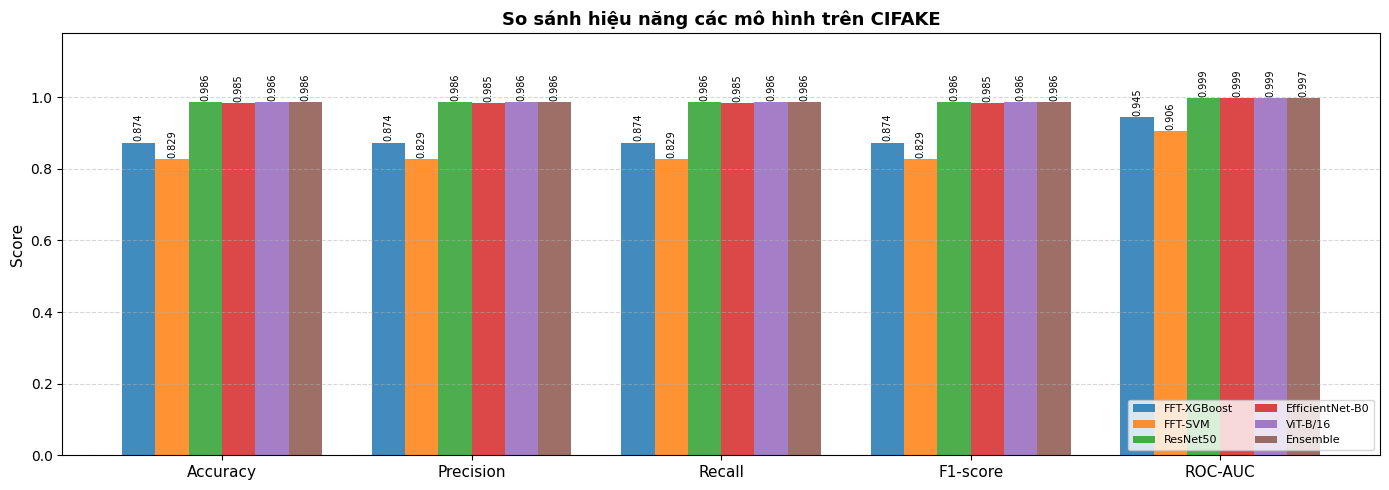

Đã lưu: results/model_comparison.png


In [ ]:
import json, glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Đọc metrics từ tất cả mô hình
model_dirs = {
    'FFT-XGBoost':    'results/xgboost',
    'FFT-SVM':        'results/svm',
    'ResNet50':       'results/resnet50',
    'EfficientNet-B0':'results/efficientnet',
    'ViT-B/16':       'results/vit',
    'Ensemble':       'results/ensemble',
}
metrics_all = {}
for name, d in model_dirs.items():
    p = Path(d) / 'metrics.json'
    if p.exists():
        metrics_all[name] = json.loads(p.read_text(encoding='utf-8'))
    else:
        print(f'[SKIP] {p} chưa có')

models  = list(metrics_all.keys())
metrics_keys = ['accuracy','precision','recall','f1','roc_auc']
labels_vn    = ['Accuracy','Precision','Recall','F1-score','ROC-AUC']

if not models:
    print('Chưa có file metrics.json nào. Hãy train/evaluate ít nhất một mô hình trước.')
else:
    # ── Bảng text ──
    print(f"{'Mô hình':<20} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC':>8}")
    print('─'*64)
    for name in models:
        m = metrics_all[name]
        print(f"{name:<20} "
              f"{m.get('accuracy',0):>8.4f} "
              f"{m.get('precision',0):>8.4f} "
              f"{m.get('recall',0):>8.4f} "
              f"{m.get('f1',0):>8.4f} "
              f"{m.get('roc_auc',0):>8.4f}")

    # ── Biểu đồ grouped bar ──
    x     = np.arange(len(metrics_keys))
    width = min(0.8 / max(len(models), 1), 0.18)
    cmap  = plt.colormaps['tab10']

    fig, ax = plt.subplots(figsize=(14,5))
    offset0 = -width * (len(models)-1) / 2
    for i, name in enumerate(models):
        vals = [metrics_all[name].get(k,0) for k in metrics_keys]
        bars = ax.bar(x + offset0 + i*width, vals, width, label=name, color=cmap(i), alpha=0.85)
        for bar,v in zip(bars,vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(labels_vn, fontsize=11)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('So sánh hiệu năng các mô hình trên CIFAKE', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8, ncol=2)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    Path('results').mkdir(exist_ok=True)
    plt.savefig('results/model_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()
    print('Đã lưu: results/model_comparison.png')


## 12. ROC Curve tổng hợp


[SKIP] results/ensemble/ensemble_probs.json


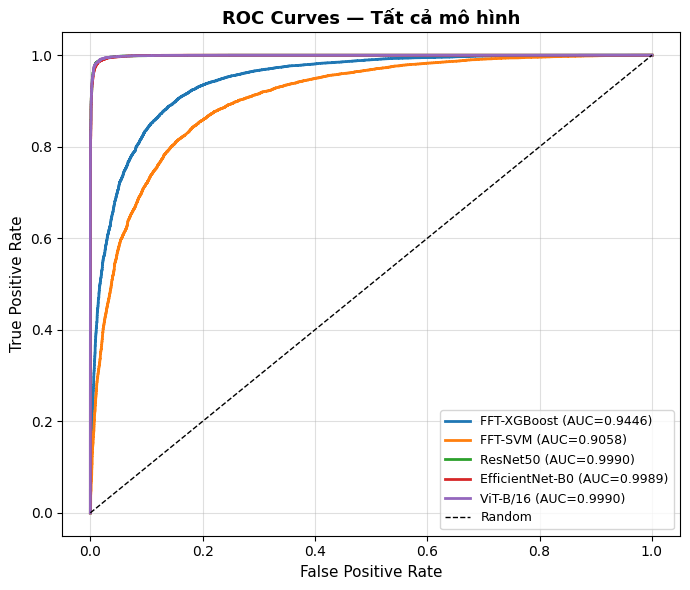

Đã lưu: results/roc_comparison.png


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, roc_auc_score

prob_files = {
    'FFT-XGBoost':    'results/xgboost/xgboost_probs.json',
    'FFT-SVM':        'results/svm/svm_probs.json',
    'ResNet50':       'results/resnet50/resnet50_probs.json',
    'EfficientNet-B0':'results/efficientnet/efficientnet_probs.json',
    'ViT-B/16':       'results/vit/vit_probs.json',
    'Ensemble':       'results/ensemble/ensemble_probs.json',
}

plt.figure(figsize=(7,6))
plotted = 0
cmap = plt.colormaps['tab10']
for i, (name, path) in enumerate(prob_files.items()):
    p = Path(path)
    if not p.exists():
        print(f'[SKIP] {path}')
        continue
    data   = json.loads(p.read_text(encoding='utf-8'))
    probs  = np.array(data['probabilities'], dtype=float)
    labels = np.array(data['labels'], dtype=int)
    if probs.ndim == 2:
        probs = probs[:, 1] if probs.shape[1] == 2 else probs.ravel()
    if len(probs) != len(labels):
        print(f'[SKIP] {name}: probabilities ({len(probs)}) khác labels ({len(labels)})')
        continue
    if len(np.unique(labels)) < 2:
        print(f'[SKIP] {name}: labels chỉ có 1 lớp, không vẽ ROC được')
        continue
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    plt.plot(fpr, tpr, color=cmap(i), label=f'{name} (AUC={auc:.4f})', linewidth=2)
    plotted += 1

if plotted == 0:
    plt.close()
    print('Chưa có probability file hợp lệ để vẽ ROC comparison.')
else:
    plt.plot([0,1],[0,1],'k--',linewidth=1,label='Random')
    plt.xlabel('False Positive Rate', fontsize=11)
    plt.ylabel('True Positive Rate', fontsize=11)
    plt.title('ROC Curves — Tất cả mô hình', fontsize=13, fontweight='bold')
    plt.legend(fontsize=9); plt.grid(alpha=0.4)
    plt.tight_layout()
    Path('results').mkdir(exist_ok=True)
    plt.savefig('results/roc_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Đã lưu: results/roc_comparison.png')


## 13. Phân tích FFT Spectrum — REAL vs FAKE
Trực quan hóa lý do tại sao FFT phân biệt được ảnh thật và ảnh AI.


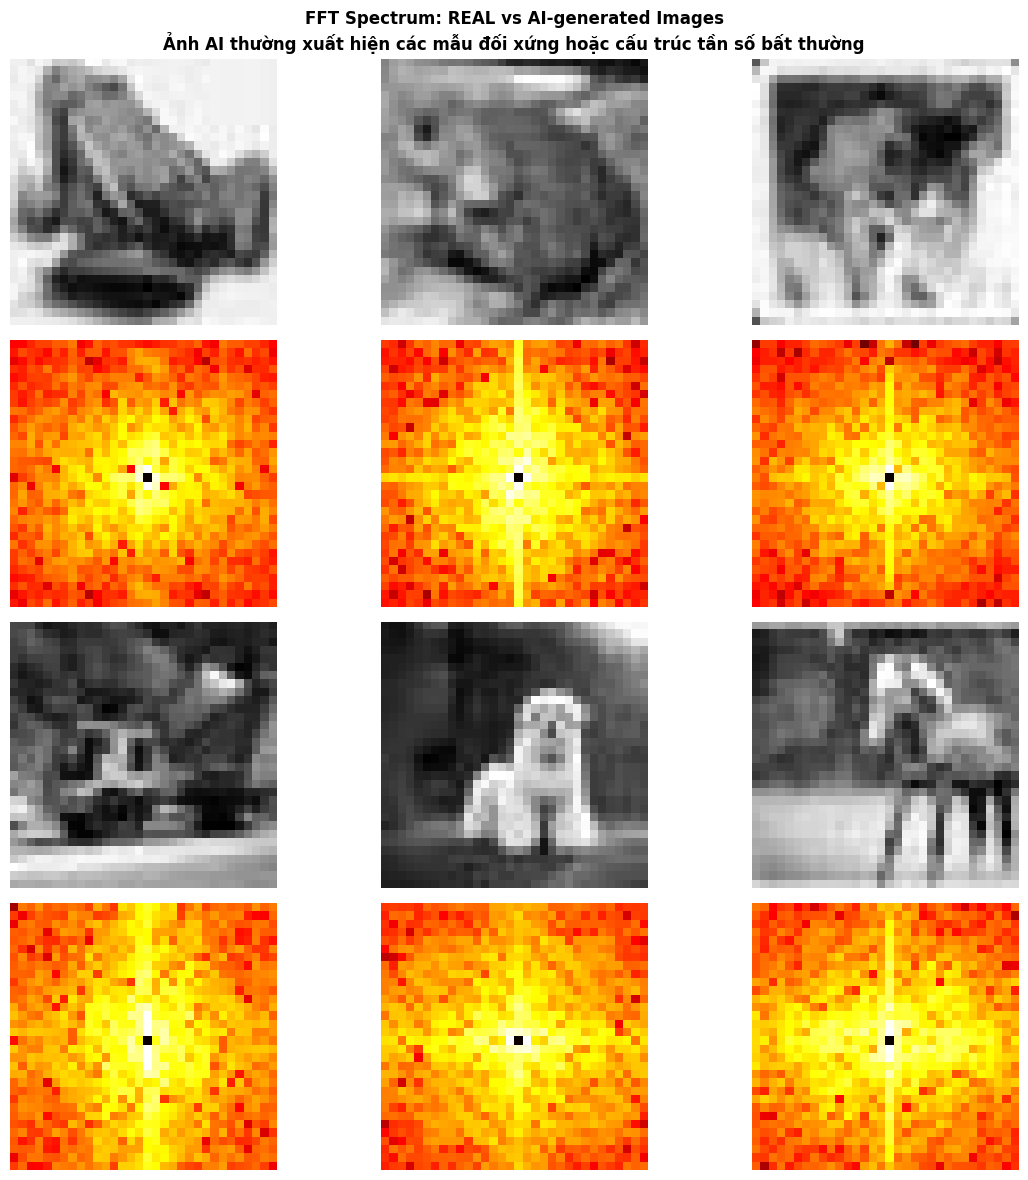

Đã lưu: results/fft_visualization.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# =========================
# Cấu hình đường dẫn
# =========================
root = Path("data/raw/cifake")
output_dir = Path("results")
output_dir.mkdir(exist_ok=True)

# =========================
# Hàm tính FFT Spectrum
# =========================
def fft_spectrum(img_path):
    img = Image.open(img_path).convert("L")
    arr = np.array(img, dtype=np.float32)

    # Loại bỏ thành phần DC để dễ quan sát
    arr = arr - arr.mean()

    fft = np.fft.fftshift(np.fft.fft2(arr))
    spectrum = np.log1p(np.abs(fft))

    # Chuẩn hóa về [0, 1]
    spectrum = (spectrum - spectrum.min()) / (
        spectrum.max() - spectrum.min() + 1e-8
    )

    return spectrum


# =========================
# Đọc danh sách ảnh
# =========================
real_pool = (
    list((root / "test" / "REAL").glob("*.jpg"))
    + list((root / "test" / "REAL").glob("*.png"))
)

fake_pool = (
    list((root / "test" / "FAKE").glob("*.jpg"))
    + list((root / "test" / "FAKE").glob("*.png"))
)

# Số lượng ảnh muốn hiển thị
n = min(3, len(real_pool), len(fake_pool))

if n == 0:
    print("Không tìm thấy đủ ảnh REAL và FAKE.")
    raise SystemExit("Không tìm thấy đủ ảnh REAL và FAKE.")

# =========================
# Tạo figure
# =========================
fig, axes = plt.subplots(
    4,
    n,
    figsize=(4 * n, 12)
)

# Trường hợp chỉ có 1 cột
if n == 1:
    axes = axes.reshape(4, 1)

# =========================
# Vẽ ảnh và FFT
# =========================
for col in range(n):

    for block, (label, img_path) in enumerate([
        ("REAL", real_pool[col]),
        ("FAKE", fake_pool[col]),
    ]):

        img = np.array(
            Image.open(img_path).convert("L")
        )

        spectrum = fft_spectrum(img_path)

        row_img = block * 2
        row_fft = block * 2 + 1

        # Ảnh gốc
        axes[row_img, col].imshow(
            img,
            cmap="gray"
        )
        axes[row_img, col].axis("off")

        # FFT Spectrum
        axes[row_fft, col].imshow(
            spectrum,
            cmap="hot"
        )
        axes[row_fft, col].axis("off")

        # Nhãn bên trái
        if col == 0:
            axes[row_img, col].set_ylabel(
                f"{label}\n(Image)",
                fontsize=10
            )

            axes[row_fft, col].set_ylabel(
                f"{label}\n(FFT)",
                fontsize=10
            )

# =========================
# Tiêu đề
# =========================
plt.suptitle(
    "FFT Spectrum: REAL vs AI-generated Images\n"
    "Ảnh AI thường xuất hiện các mẫu đối xứng hoặc cấu trúc tần số bất thường",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()

save_path = output_dir / "fft_visualization.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(f"Đã lưu: {save_path}")

## 14. Grad-CAM — Giải thích mô hình CNN

**Grad-CAM (Gradient-weighted Class Activation Mapping)** trực quan hóa vùng ảnh
mà mô hình tập trung vào khi quyết định REAL/FAKE.

Áp dụng cho: ResNet50 và EfficientNet-B0 (CNN có feature map).

ViT có Attention Rollout riêng — không dùng Grad-CAM.


### 14.1 Viết GradCAM class


In [ ]:
%%writefile gradcam.py
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from torchvision import transforms


class GradCAM:
    """Grad-CAM cho bất kỳ CNN nào.

    Cách dùng:
        cam = GradCAM(model, target_layer)
        heatmap, pred_class, prob = cam(img_tensor)
    """
    def __init__(self, model, target_layer):
        self.model       = model
        self.target_layer = target_layer
        self.gradients   = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, x: torch.Tensor, class_idx: int = None):
        """x: (1, C, H, W). Trả về (heatmap H×W, pred_class, prob)."""
        self.model.eval()
        self.model.zero_grad()

        # Forward
        logits = self.model(x)                            # (1, num_classes)
        probs  = torch.softmax(logits, dim=1)[0]          # (num_classes,)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        # Backward — chỉ gradient của class_idx
        score = logits[0, class_idx]
        score.backward()

        # Grad-CAM: global average pooling của gradient
        # weights: (C,)
        weights = self.gradients.mean(dim=(2, 3))[0]      # mean over H, W
        acts    = self.activations[0]                      # (C, H, W)

        # Weighted sum of activation maps
        cam = torch.zeros(acts.shape[1:], dtype=torch.float32)
        for i, w in enumerate(weights):
            cam += w * acts[i]

        # ReLU + normalize
        cam = F.relu(cam)
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        return cam.numpy(), class_idx, float(probs[class_idx])


def get_target_layer(model, model_name: str):
    """Lấy layer cuối cùng trước pooling — nơi feature map còn spatial info."""
    if model_name == 'ResNet50':
        return model.layer4[-1]            # Bottleneck block cuối
    elif model_name == 'EfficientNet-B0':
        return model.blocks[-1][-1]        # MBConv block cuối
    else:
        raise ValueError(f'Chưa hỗ trợ Grad-CAM cho {model_name}')


def visualize_gradcam(
    model,
    model_name: str,
    img_pil: Image.Image,
    class_names: dict = {0: 'FAKE', 1: 'REAL'},
    img_size: int = 224,
    alpha: float = 0.45,
    save_path: str = None,
) -> plt.Figure:
    """Tạo hình Grad-CAM overlay lên ảnh gốc.

    Args:
        model:      CNN model (ResNet50 hoặc EfficientNet-B0)
        model_name: 'ResNet50' hoặc 'EfficientNet-B0'
        img_pil:    ảnh PIL đầu vào
        class_names: mapping index → tên lớp
        alpha:      độ mờ của heatmap overlay
        save_path:  nếu không None, lưu file PNG

    Returns:
        matplotlib Figure
    """
    # Preprocess
    tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    x = tf(img_pil.convert('RGB')).unsqueeze(0)
    x.requires_grad_(True)

    # Grad-CAM
    target_layer = get_target_layer(model, model_name)
    cam_obj      = GradCAM(model, target_layer)
    heatmap, pred_idx, prob = cam_obj(x)

    # Resize heatmap về kích thước ảnh gốc
    heatmap_pil = Image.fromarray(np.uint8(255 * heatmap))
    heatmap_pil = heatmap_pil.resize(img_pil.size, Image.BILINEAR)
    heatmap_np  = np.array(heatmap_pil) / 255.0

    # Colormap: jet
    colormap   = plt.colormaps['jet']
    heatmap_rgb = colormap(heatmap_np)[:, :, :3]  # (H, W, 3)

    # Overlay
    img_np  = np.array(img_pil.convert('RGB')) / 255.0
    overlay = (1 - alpha) * img_np + alpha * heatmap_rgb
    overlay = np.clip(overlay, 0, 1)

    # Plot
    label = class_names.get(pred_idx, str(pred_idx))
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img_pil); axes[0].set_title('Ảnh gốc', fontsize=12); axes[0].axis('off')

    axes[1].imshow(heatmap_np, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12); axes[1].axis('off')
    plt.colorbar(cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1)), ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(overlay)
    axes[2].set_title(
        f'Overlay — Dự đoán: {label} ({prob:.1%})',
        fontsize=12, color='red' if label=='FAKE' else 'green', fontweight='bold'
    )
    axes[2].axis('off')

    plt.suptitle(
        f'Grad-CAM — {model_name}\n'
        f'Vùng đỏ/vàng = nơi mô hình tập trung để nhận dạng {label}',
        fontsize=11, y=1.02
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Đã lưu: {save_path}')

    return fig


if __name__ == '__main__':
    print('GradCAM module loaded OK')


Writing gradcam.py


### 14.2 Test Grad-CAM trên ảnh mẫu


Loaded ResNet50
Grad-CAM cho ảnh REAL: 0750 (4).jpg


/content/gradcam.py:65: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return cam.numpy(), class_idx, float(probs[class_idx])


Đã lưu: results/gradcam/resnet50_real.png


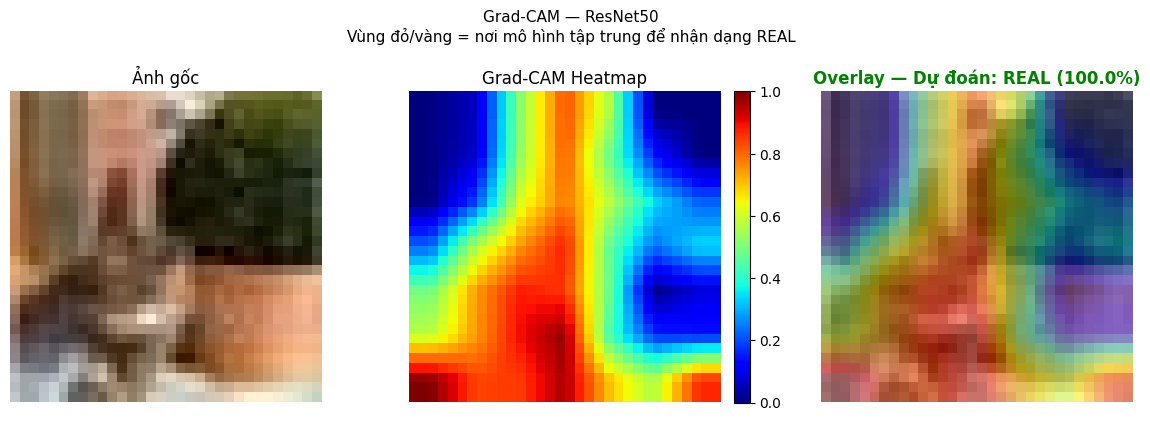

Grad-CAM cho ảnh FAKE: 539 (4).jpg
Đã lưu: results/gradcam/resnet50_fake.png


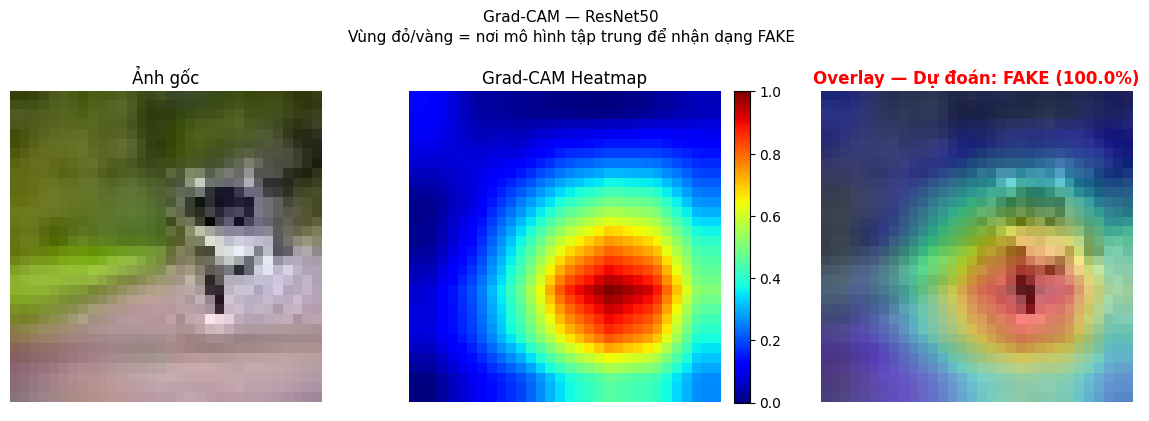

In [ ]:
from gradcam import visualize_gradcam, get_target_layer
from torchvision import models
from pathlib import Path
import torch.nn as nn
import torch
import random

# ── Load ResNet50 đã train ────────────────────────────────────────────────
weights_path = Path('results/resnet50/resnet50_weights.pth')
root = Path('data/raw/cifake/test')

if not weights_path.exists():
    print('Chưa có ResNet50 weights. Chạy Section 7 trước.')
elif not (root/'REAL').exists() or not (root/'FAKE').exists():
    print('Chưa thấy data test/REAL và test/FAKE. Chạy Section 3 trước.')
else:
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
    model.eval()
    print('Loaded ResNet50')

    # ── Lấy ảnh mẫu: 1 REAL + 1 FAKE ────────────────────────────────────
    from PIL import Image
    import matplotlib.pyplot as plt

    real_pool = list((root/'REAL').glob('*.jpg')) + list((root/'REAL').glob('*.png'))
    fake_pool = list((root/'FAKE').glob('*.jpg')) + list((root/'FAKE').glob('*.png'))
    if not real_pool or not fake_pool:
        print('Không đủ ảnh REAL/FAKE để vẽ Grad-CAM.')
    else:
        samples = {'REAL': random.choice(real_pool), 'FAKE': random.choice(fake_pool)}
        Path('results/gradcam').mkdir(parents=True, exist_ok=True)

        for label, img_path in samples.items():
            img = Image.open(img_path).convert('RGB')  # no pre-resize; visualize_gradcam handles resizing
            print(f'Grad-CAM cho ảnh {label}: {img_path.name}')
            fig = visualize_gradcam(
                model, 'ResNet50', img,
                save_path=f'results/gradcam/resnet50_{label.lower()}.png'
            )
            plt.show()
            plt.close()


### 14.3 Grad-CAM so sánh nhiều ảnh REAL vs FAKE


Đã lưu: results/gradcam/compare_REAL_0750 (4).png


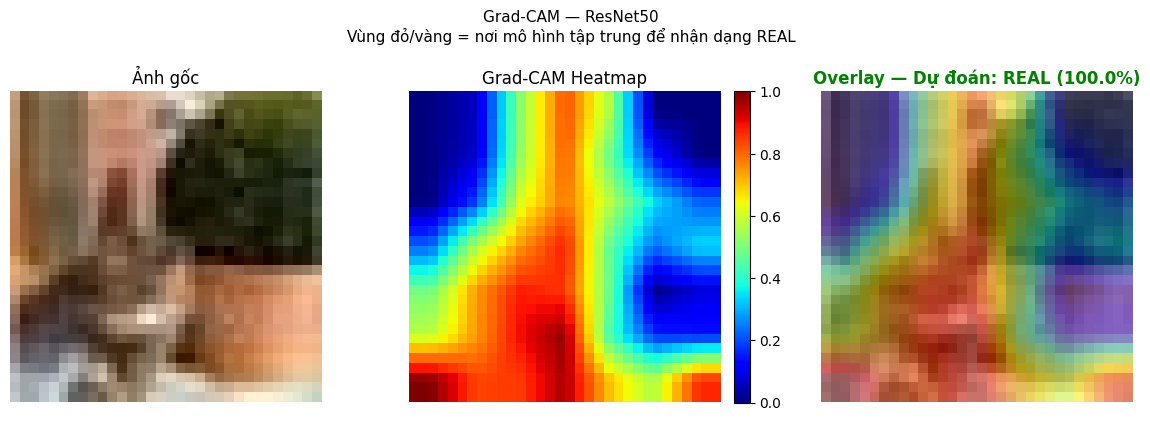

Đã lưu: results/gradcam/compare_REAL_0467 (4).png


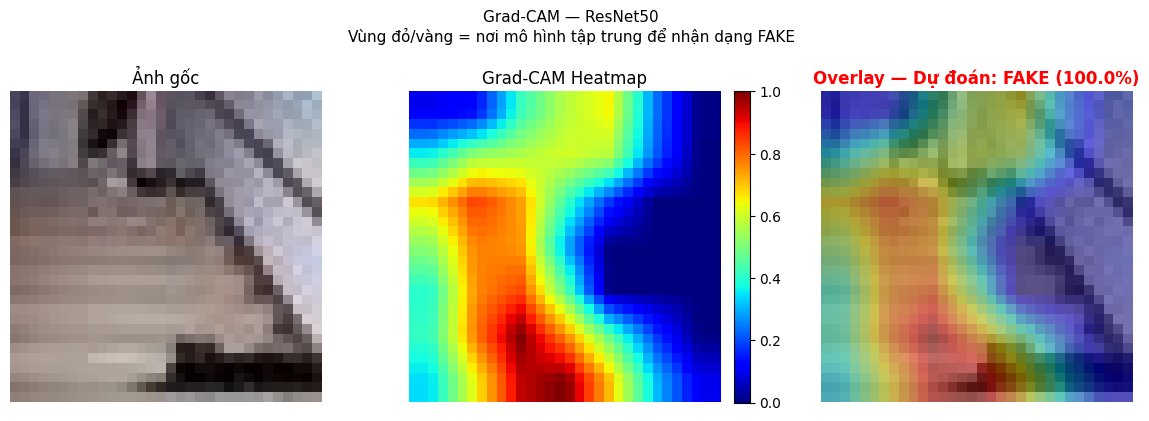

Đã lưu: results/gradcam/compare_REAL_0893 (7).png


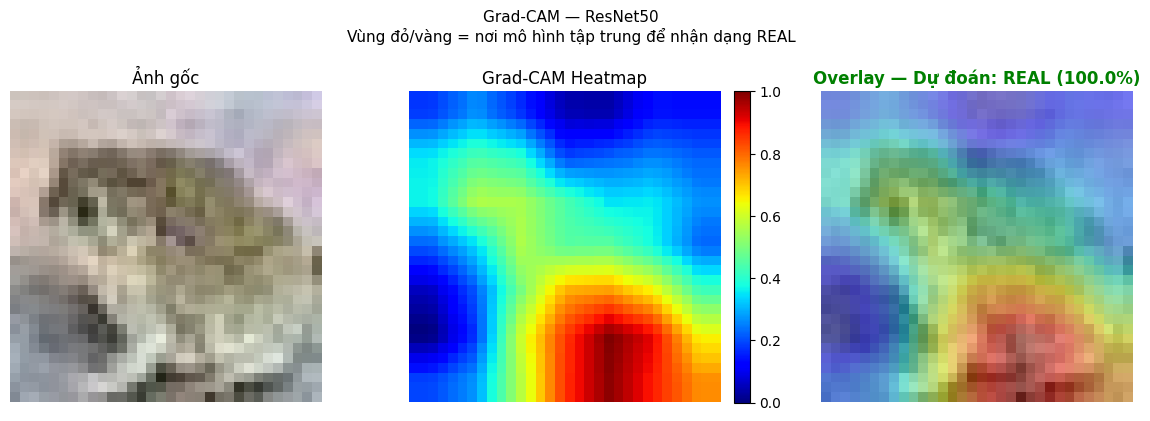

Đã lưu: results/gradcam/compare_FAKE_67 (8).png


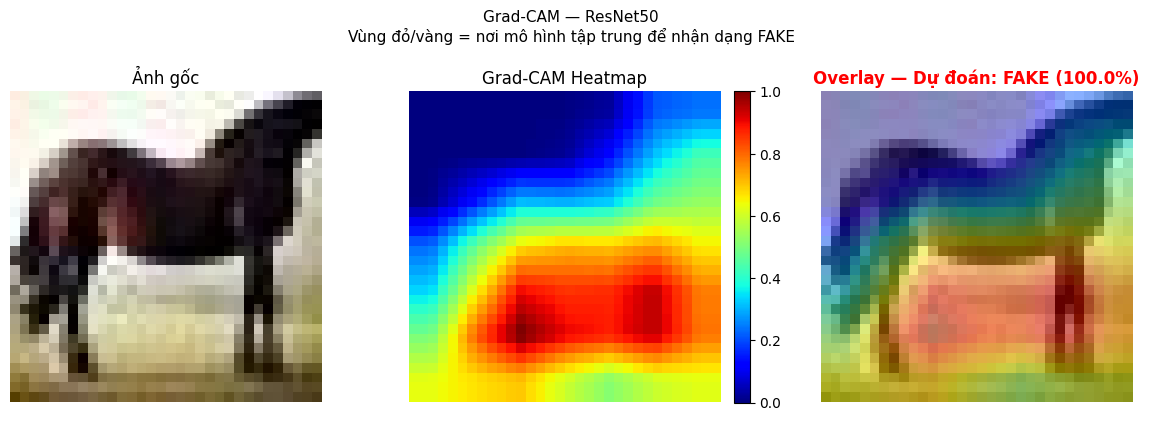

Đã lưu: results/gradcam/compare_FAKE_270 (5).png


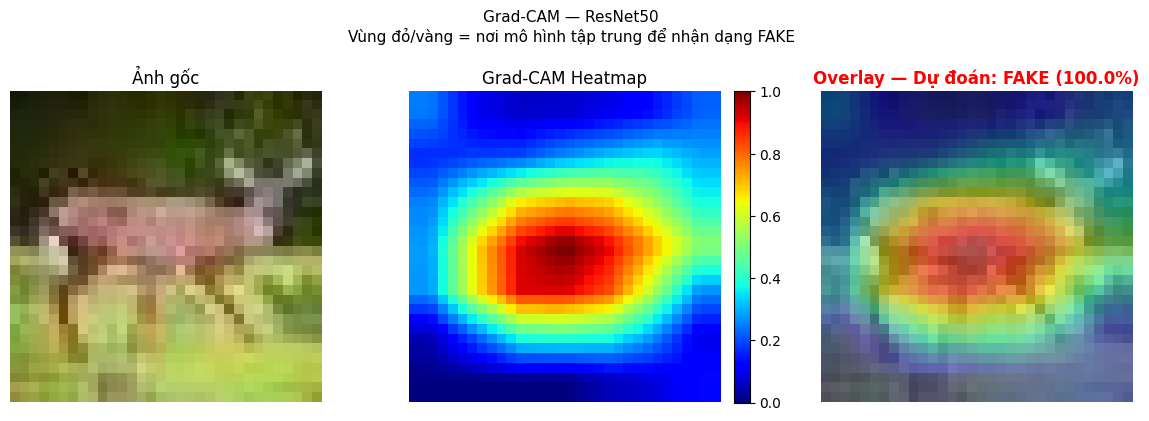

Đã lưu: results/gradcam/compare_FAKE_765 (3).png


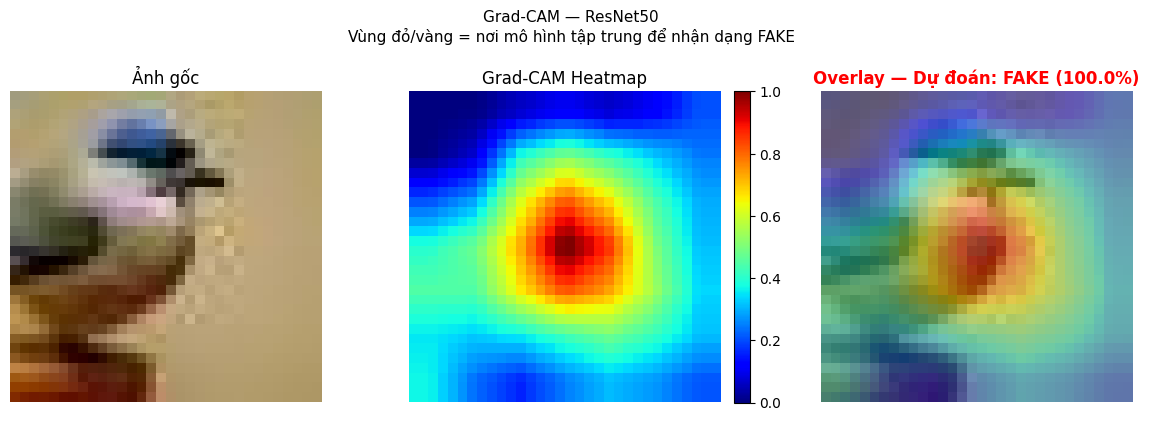

Grad-CAM xong! File ảnh lưu tại results/gradcam/


In [ ]:
from gradcam import visualize_gradcam
import random
random.seed(42)  # reproducible sampling
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

# Lấy nhiều ảnh REAL/FAKE để so sánh Grad-CAM ResNet50
root = Path('data/raw/cifake/test')
n_samples = 3

try:
    _check_model = model  # noqa: F821
except NameError:
    print('Chưa có biến model ResNet50. Hãy chạy cell 14.2 trước.')
    _check_model = None

if '_check_model' in dir() and _check_model is not None and (not (root/'REAL').exists() or not (root/'FAKE').exists()):
    print('Chưa thấy data test/REAL và test/FAKE. Chạy Section 3 trước.')
elif '_check_model' in dir() and _check_model is not None:
    real_pool = list((root/'REAL').glob('*.jpg')) + list((root/'REAL').glob('*.png'))
    fake_pool = list((root/'FAKE').glob('*.jpg')) + list((root/'FAKE').glob('*.png'))
    if len(real_pool) < 1 or len(fake_pool) < 1:
        print('Không đủ ảnh để vẽ Grad-CAM.')
    else:
        Path('results/gradcam').mkdir(parents=True, exist_ok=True)
        real_imgs = random.sample(real_pool, min(n_samples, len(real_pool)))
        fake_imgs = random.sample(fake_pool, min(n_samples, len(fake_pool)))

        for label, paths in [('REAL', real_imgs), ('FAKE', fake_imgs)]:
            for img_path in paths:
                img = Image.open(img_path).convert('RGB')  # visualize_gradcam handles resizing
                fig = visualize_gradcam(
                    model, 'ResNet50', img,
                    save_path=f"results/gradcam/compare_{label}_{img_path.stem}.png"
                )
                plt.show()
                plt.close()

        print('Grad-CAM xong! File ảnh lưu tại results/gradcam/')


### 14.4 Grad-CAM cho EfficientNet-B0


Loaded EfficientNet-B0
Đã lưu: results/gradcam/efficientnet_real.png


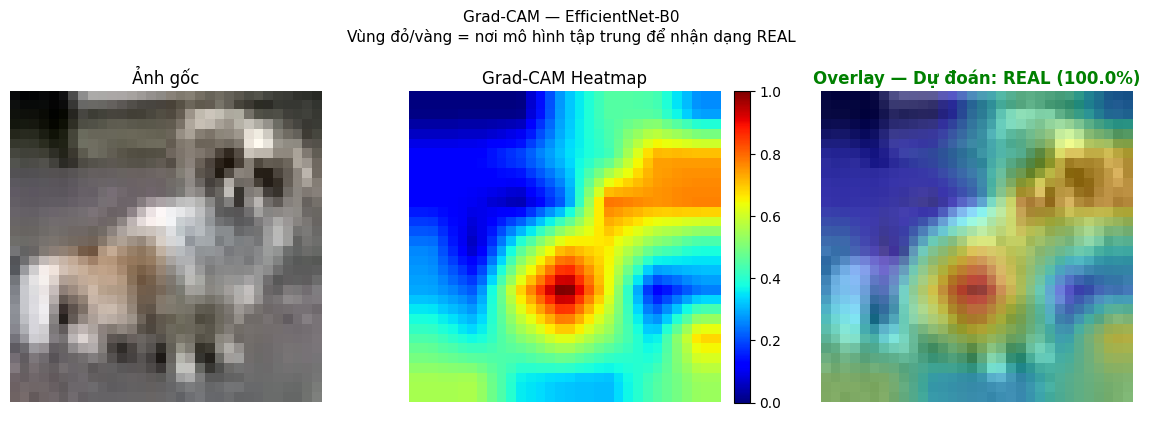

Đã lưu: results/gradcam/efficientnet_fake.png


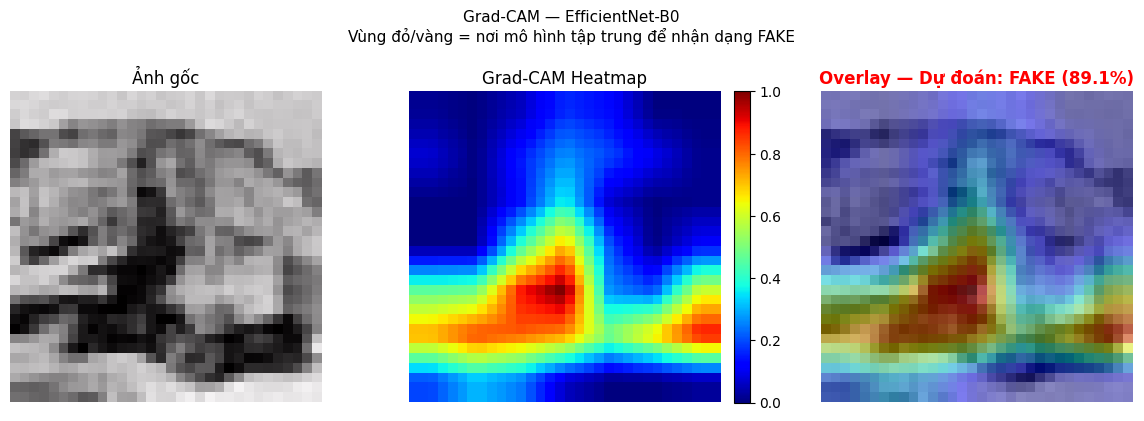

In [ ]:
import timm
from gradcam import visualize_gradcam
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random, torch

eff_weights = Path('results/efficientnet/efficientnet_weights.pth')
root = Path('data/raw/cifake/test')

if not eff_weights.exists():
    print('Chưa có EfficientNet weights. Bỏ qua.')
elif not (root/'REAL').exists() or not (root/'FAKE').exists():
    print('Chưa thấy data test/REAL và test/FAKE. Chạy Section 3 trước.')
else:
    eff_model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2)
    eff_model.load_state_dict(torch.load(eff_weights, map_location='cpu', weights_only=True))
    eff_model.eval()
    print('Loaded EfficientNet-B0')
    Path('results/gradcam').mkdir(parents=True, exist_ok=True)

    for label in ['REAL', 'FAKE']:
        pool = list((root/label).glob('*.jpg')) + list((root/label).glob('*.png'))
        if not pool:
            print(f'Không có ảnh {label}.')
            continue
        img_path = random.choice(pool)
        img = Image.open(img_path).convert('RGB')  # visualize_gradcam handles resizing
        fig = visualize_gradcam(
            eff_model, 'EfficientNet-B0', img,
            save_path=f'results/gradcam/efficientnet_{label.lower()}.png'
        )
        plt.show()
        plt.close()


## 15. Web App — Streamlit




### 15.1 File app_v2.py


In [ ]:
%%writefile app_v2.py
import json
from pathlib import Path

import numpy as np
import streamlit as st
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from torchvision import models, transforms
from PIL import Image
from xgboost import XGBClassifier

# ── Đường dẫn ─────────────────────────────────────────────────────────────────
GDRIVE_ROOT = Path("/content/drive/MyDrive/")
LOCAL_ROOT  = Path("results")

MODEL_FILES = {
    "FFT-XGBoost":    {"file": "xgboost/xgboost_model.json",            "type": "xgb"},
    "ResNet50":        {"file": "resnet50/resnet50_weights.pth",          "type": "cnn"},
    "EfficientNet-B0": {"file": "efficientnet/efficientnet_weights.pth",  "type": "cnn"},
    "ViT-B/16":        {"file": "vit/vit_weights.pth",                   "type": "vit"},
}

GRADCAM_SUPPORT = {"ResNet50", "EfficientNet-B0"}

FFT_SIZE = 64

# ── Tìm weights ───────────────────────────────────────────────────────────────
def find_weights(rel_path: str):
    for root in [LOCAL_ROOT, GDRIVE_ROOT]:
        p = root / rel_path
        if p.exists():
            return p
    return None

def available_models():
    return [name for name, cfg in MODEL_FILES.items()
            if find_weights(cfg["file"]) is not None]

# ── Transforms ────────────────────────────────────────────────────────────────
cnn_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
vit_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

# ── Load models (cache) ───────────────────────────────────────────────────────
@st.cache_resource
def load_resnet(path: str):
    m = models.resnet50(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 2)
    m.load_state_dict(torch.load(path, map_location="cpu", weights_only=True))
    return m.eval()

@st.cache_resource
def load_efficientnet(path: str):
    m = timm.create_model("efficientnet_b0", pretrained=False, num_classes=2)
    m.load_state_dict(torch.load(path, map_location="cpu", weights_only=True))
    return m.eval()

@st.cache_resource
def load_vit(path: str):
    m = timm.create_model("vit_base_patch16_224", pretrained=False, num_classes=2)
    m.load_state_dict(torch.load(path, map_location="cpu", weights_only=True))
    return m.eval()

@st.cache_resource
def load_xgb(path: str):
    clf = XGBClassifier()
    clf.load_model(path)
    return clf

def get_model(name: str):
    p = find_weights(MODEL_FILES[name]["file"])
    if p is None:
        return None
    ps = str(p)
    if name == "FFT-XGBoost":    return load_xgb(ps)
    if name == "ResNet50":        return load_resnet(ps)
    if name == "EfficientNet-B0": return load_efficientnet(ps)
    if name == "ViT-B/16":        return load_vit(ps)

# ── FFT ───────────────────────────────────────────────────────────────────────
def extract_fft(img: Image.Image) -> np.ndarray:
    gray = img.convert("L").resize((FFT_SIZE, FFT_SIZE))
    arr  = np.array(gray, dtype=np.float32)
    fft  = np.fft.fftshift(np.fft.fft2(arr))
    return np.log1p(np.abs(fft)).flatten().reshape(1, -1)

def fft_spectrum_2d(img: Image.Image) -> np.ndarray:
    gray = img.convert("L").resize((FFT_SIZE, FFT_SIZE))
    arr  = np.array(gray, dtype=np.float32)
    return np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(arr))))

# ── Predict ───────────────────────────────────────────────────────────────────
def predict(name: str, img: Image.Image):
    model = get_model(name)
    if model is None:
        return None
    if name == "FFT-XGBoost":
        return float(model.predict_proba(extract_fft(img))[0, 1])
    tf = vit_tf if name == "ViT-B/16" else cnn_tf
    x  = tf(img.convert("RGB")).unsqueeze(0)
    with torch.no_grad():
        prob = torch.softmax(model(x), dim=1)[0]
    return float(prob[0])   # FAKE=0 in ImageFolder -> prob[0] = P(FAKE)

def predict_ensemble(img: Image.Image, w1=0.6):
    pr = predict("ResNet50", img)
    px = predict("FFT-XGBoost", img)
    if pr is None or px is None:
        return None
    return w1 * pr + (1 - w1) * px

# ── Grad-CAM ──────────────────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.gradients    = None
        self.activations  = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0].detach()))

    def __call__(self, x: torch.Tensor, class_idx: int = None):
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(x)
        probs  = torch.softmax(logits, dim=1)[0]
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        logits[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3))[0]
        acts    = self.activations[0]
        cam     = sum(w * a for w, a in zip(weights, acts))
        cam     = F.relu(cam)
        cam    -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam.numpy(), class_idx, float(probs[class_idx])

def get_target_layer(model, name: str):
    if name == "ResNet50":
        return model.layer4[-1]
    if name == "EfficientNet-B0":
        return model.blocks[-1][-1]
    raise ValueError(f"Grad-CAM chưa hỗ trợ {name}")

def make_gradcam_fig(model, model_name: str, img_pil: Image.Image, alpha=0.45):
    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    x = tf(img_pil.convert("RGB")).unsqueeze(0)
    x.requires_grad_(True)

    target_layer = get_target_layer(model, model_name)
    cam_fn       = GradCAM(model, target_layer)
    heatmap, pred_idx, prob = cam_fn(x)

    hm_pil = Image.fromarray(np.uint8(255 * heatmap)).resize(
        img_pil.size, Image.BILINEAR)
    hm_np  = np.array(hm_pil) / 255.0

    colormap   = plt.colormaps["jet"]
    hm_rgb     = colormap(hm_np)[:, :, :3]
    img_np     = np.array(img_pil.convert("RGB")) / 255.0
    overlay    = np.clip((1 - alpha) * img_np + alpha * hm_rgb, 0, 1)

    label       = {0:"FAKE", 1:"REAL"}.get(pred_idx, str(pred_idx))
    label_color = "red" if label == "FAKE" else "green"

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_pil);            axes[0].set_title("Ảnh gốc");      axes[0].axis("off")
    axes[1].imshow(hm_np, cmap="jet");  axes[1].set_title("Heatmap");      axes[1].axis("off")
    plt.colorbar(cm.ScalarMappable(cmap="jet", norm=plt.Normalize(0, 1)), ax=axes[1], fraction=0.046, pad=0.04)
    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay — {label} ({prob:.1%})", color=label_color, fontweight="bold")
    axes[2].axis("off")

    plt.suptitle(
        f"Grad-CAM — {model_name}\n"
        f"Vùng đỏ/vàng = nơi mô hình tập trung để nhận dạng {label}",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    return fig

# ── UI helpers ────────────────────────────────────────────────────────────────
def show_result(label_str: str, prob_fake: float, threshold: float):
    is_fake = prob_fake >= threshold
    label   = "🤖 FAKE (AI-generated)" if is_fake else "✅ REAL (Ảnh thật)"
    color   = "#FF4B4B" if is_fake else "#21BA45"
    conf    = prob_fake if is_fake else 1 - prob_fake
    st.markdown(
        f'<div style="background:{color};padding:10px 18px;border-radius:10px;'
        f'color:white;font-size:18px;font-weight:bold;margin-bottom:8px">'
        f'{label_str}: {label} — {conf:.1%}</div>',
        unsafe_allow_html=True
    )
    st.progress(float(prob_fake), text=f"P(FAKE) = {prob_fake:.4f}")

def prob_bar_chart(prob: float):
    fig, ax = plt.subplots(figsize=(6, 2))
    ax.barh(["REAL","FAKE"], [1-prob, prob], color=["#21BA45","#FF4B4B"])
    ax.set_xlim(0, 1); ax.set_xlabel("Xác suất")
    for i, v in enumerate([1-prob, prob]):
        ax.text(min(v+0.02,0.88), i, f"{v:.4f}", va="center", fontsize=12, fontweight="bold")
    plt.tight_layout()
    st.pyplot(fig); plt.close()

def compare_bar_chart(results: dict, threshold: float):
    fig, ax = plt.subplots(figsize=(7, max(2.5, len(results)*0.6)))
    names  = list(results.keys())
    probs  = [results[n] for n in names]
    colors = ["#FF4B4B" if p >= threshold else "#21BA45" for p in probs]
    bars   = ax.barh(names, probs, color=colors)
    ax.axvline(threshold, color="gray", linestyle="--", label=f"Ngưỡng {threshold:.2f}")
    ax.set_xlim(0, 1); ax.set_xlabel("P(FAKE)"); ax.legend()
    for bar, v in zip(bars, probs):
        ax.text(min(v+0.02,0.92), bar.get_y()+bar.get_height()/2,
                f"{v:.3f}", va="center", fontsize=11)
    plt.tight_layout()
    st.pyplot(fig); plt.close()

# ── Save to Drive ─────────────────────────────────────────────────────────────
def save_to_drive():
    try:
        from google.colab import drive
        import shutil
        drive.mount("/content/drive")
        GDRIVE_ROOT.mkdir(parents=True, exist_ok=True)
        if LOCAL_ROOT.exists():
            shutil.copytree(str(LOCAL_ROOT), str(GDRIVE_ROOT), dirs_exist_ok=True)
        st.success(f"✓ Đã lưu lên Google Drive: {GDRIVE_ROOT}")
    except ImportError:
        st.warning("Không phải môi trường Colab.")
    except Exception as e:
        st.error(f"Lỗi: {e}")

# ════════════════════════════════════════════════════════════════════════════════
# MAIN
# ════════════════════════════════════════════════════════════════════════════════
def main():
    st.set_page_config(page_title="AI Image Detector", page_icon="🔍", layout="wide")

    st.title("🔍 Phát hiện ảnh do AI tạo ra")
    st.caption("AI-Generated Image Detection + Grad-CAM XAI — Nhóm 3T | UIT 2025")

    # ── Sidebar ───────────────────────────────────────────────────────────────
    st.sidebar.title("⚙️ Cài đặt")

    avail = available_models()
    if not avail:
        st.sidebar.error("❌ Chưa có model nào!")
    else:
        st.sidebar.success(f"✓ Sẵn sàng: {len(avail)} mô hình")

    model_options = avail.copy()
    has_ensemble  = "ResNet50" in avail and "FFT-XGBoost" in avail
    if has_ensemble:
        model_options.append("Ensemble")
    if len(model_options) > 1:
        model_options.append("So sánh tất cả")

    model_name = st.sidebar.selectbox("Chọn mô hình", model_options) if model_options else None

    show_fft     = st.sidebar.checkbox("FFT Spectrum", value=True)
    show_gradcam = st.sidebar.checkbox("Grad-CAM (CNN only)", value=True)
    threshold    = st.sidebar.slider("Ngưỡng FAKE", 0.0, 1.0, 0.5, 0.01)

    st.sidebar.markdown("---")
    st.sidebar.markdown("**Trạng thái models:**")
    for name, cfg in MODEL_FILES.items():
        p    = find_weights(cfg["file"])
        icon = "✅" if p else "⬜"
        src  = "(Drive)" if p and "drive" in str(p) else "(local)" if p else ""
        st.sidebar.markdown(f"{icon} {name} {src}")

    st.sidebar.markdown("---")
    if st.sidebar.button("💾 Lưu lên Google Drive"):
        save_to_drive()

    with st.sidebar.expander("📤 Upload weights thủ công"):
        up_target = st.selectbox("Model", list(MODEL_FILES.keys()), key="up_model")
        up_file   = st.file_uploader("File .pth / .json", type=["pth","json"], key="up_file")
        if up_file and st.button("Lưu"):
            dest = LOCAL_ROOT / MODEL_FILES[up_target]["file"]
            dest.parent.mkdir(parents=True, exist_ok=True)
            dest.write_bytes(up_file.read())
            st.success(f"✓ Lưu: {dest}")
            st.cache_resource.clear()
            st.rerun()

    # ── Upload ảnh ────────────────────────────────────────────────────────────
    st.markdown("---")
    uploaded = st.file_uploader(
        "📤 Upload ảnh cần kiểm tra (JPG / PNG / WEBP)", type=["jpg","jpeg","png","webp"])

    if not uploaded:
        st.info("👆 Upload ảnh để bắt đầu phân tích.")
        return
    if not model_options:
        st.error("Chưa có model nào. Hãy train ít nhất 1 mô hình.")
        return

    img = Image.open(uploaded).convert("RGB")
    col_img, col_result = st.columns([1, 2])

    with col_img:
        st.image(img, caption=f"{img.size[0]}×{img.size[1]} px", use_container_width=True)
        if show_fft:
            spec = fft_spectrum_2d(img)
            fig, ax = plt.subplots(figsize=(4, 4))
            ax.imshow(spec, cmap="hot"); ax.set_title("FFT Spectrum"); ax.axis("off")
            st.pyplot(fig); plt.close()

    with col_result:
        st.markdown("### 📊 Kết quả")

        if model_name == "So sánh tất cả":
            results = {}
            with st.spinner("Đang chạy..."):
                for name in avail:
                    p = predict(name, img)
                    if p is not None:
                        results[name] = p
                if has_ensemble:
                    pe = predict_ensemble(img)
                    if pe is not None:
                        results["Ensemble"] = pe
            for name, prob in results.items():
                show_result(name, prob, threshold)
            if results:
                st.markdown("#### Tổng hợp P(FAKE)")
                compare_bar_chart(results, threshold)

        elif model_name == "Ensemble":
            with st.spinner("Tính Ensemble..."):
                prob = predict_ensemble(img)
            if prob is None:
                st.error("Cần ResNet50 + FFT-XGBoost.")
            else:
                show_result("Ensemble (ResNet50×0.6 + XGBoost×0.4)", prob, threshold)
                prob_bar_chart(prob)

        else:
            with st.spinner(f"Phân tích với {model_name}..."):
                prob = predict(model_name, img)
            if prob is None:
                st.error(f"Chưa có weights cho {model_name}.")
            else:
                show_result(model_name, prob, threshold)
                prob_bar_chart(prob)

        st.caption(
            "⚠️ Kết quả tham khảo. Train trên CIFAKE (SD v1.4) — "
            "có thể kém chính xác với Midjourney, DALL-E 3, FLUX."
        )

    # ── Grad-CAM: full width bên dưới ────────────────────────────────────────
    active_cnn = model_name if model_name in GRADCAM_SUPPORT else None
    if active_cnn is None and model_name == "So sánh tất cả":
        for name in ["ResNet50", "EfficientNet-B0"]:
            if name in avail:
                active_cnn = name
                break

    if show_gradcam and active_cnn:
        st.markdown("---")
        st.markdown(f"### 🔬 Grad-CAM — {active_cnn}")
        st.caption(
            "Grad-CAM trực quan hóa vùng ảnh mà mô hình tập trung vào để đưa ra quyết định."
        )
        with st.spinner("Đang tính Grad-CAM..."):
            model = get_model(active_cnn)
            if model is not None:
                try:
                    fig = make_gradcam_fig(model, active_cnn, img)
                    st.pyplot(fig); plt.close()
                    st.markdown(
                        "**Đọc kết quả:** 🔴 Đỏ/Vàng = vùng ảnh hưởng lớn nhất đến quyết định  |  "
                        "🔵 Xanh/Tím = ít ảnh hưởng.  Ảnh FAKE thường có vùng nóng tại texture "
                        "bất thường hoặc artifact viền; ảnh REAL tập trung vào đặc điểm tự nhiên."
                    )
                except Exception as e:
                    st.warning(f"Grad-CAM lỗi: {e}")
    elif show_gradcam and model_name not in GRADCAM_SUPPORT and model_name not in ["So sánh tất cả","Ensemble", None]:
        st.info("💡 Grad-CAM chỉ hỗ trợ ResNet50 và EfficientNet-B0.")


if __name__ == "__main__":
    main()



Writing app_v2.py


### 15.2 Cài thư viện demo


### 15.3 Kiểm tra models khả dụng


In [ ]:
import os
from pathlib import Path

# Danh sách weights cần thiết cho app_v2.py
REQUIRED_WEIGHTS = {
    "ResNet50":        "results/resnet50/resnet50_weights.pth",
    "EfficientNet-B0": "results/efficientnet/efficientnet_weights.pth",
    "ViT-B/16":        "results/vit/vit_weights.pth",
    "XGBoost":         "results/xgboost/xgboost_model.json",
}

print("Kiểm tra weights models:")
all_ok = True
for name, path in REQUIRED_WEIGHTS.items():
    exists = Path(path).exists()
    status = '✓' if exists else '✗ THIẾU'
    size   = f"({Path(path).stat().st_size / 1e6:.1f} MB)" if exists else ''
    print(f"  {status}  {name:<20} {path} {size}")
    if not exists:
        all_ok = False

print()
if all_ok:
    print("✅ Tất cả weights sẵn sàng — có thể chạy Streamlit.")
else:
    print("⚠  Một số weights còn thiếu. Hãy chạy các bước training trước (Mục 6–10).")


Kiểm tra weights models:
  ✓  ResNet50             results/resnet50/resnet50_weights.pth (94.4 MB)
  ✓  EfficientNet-B0      results/efficientnet/efficientnet_weights.pth (16.3 MB)
  ✓  ViT-B/16             results/vit/vit_weights.pth (343.3 MB)
  ✓  XGBoost              results/xgboost/xgboost_model.json (2.3 MB)

✅ Tất cả weights sẵn sàng — có thể chạy Streamlit.


In [ ]:
!pip install -q streamlit pyngrok



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 70.4 MB/s eta 0:00:00


### 15.4 Chạy Streamlit




In [ ]:
import subprocess, time, os
from pyngrok import ngrok, conf


NGROK_TOKEN = os.environ.get('NGROK_TOKEN', '3FSH2IK0T6KwJoAcG5XsozwGc0o_5hc2Bd4pThyRvHMXKX745')  # Set via: os.environ['NGROK_TOKEN'] = 'your_token'
if NGROK_TOKEN:
    conf.get_default().auth_token = NGROK_TOKEN

# ── Chạy Streamlit ở background ──────────────────────────────────────────
PORT = 8501
proc = subprocess.Popen(
    ['streamlit', 'run', 'app_v2.py',
     '--server.port', str(PORT),
     '--server.headless', 'true',
     '--server.enableCORS', 'false',
     '--server.enableXsrfProtection', 'false'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

# Đợi Streamlit khởi động (poll port cho đến khi ready)
import socket
for _ in range(20):
    try:
        with socket.create_connection(('localhost', PORT), timeout=1):
            break
    except OSError:
        time.sleep(0.5)
time.sleep(1)  # thêm buffer

# ── Tạo public URL qua ngrok ──────────────────────────────────────────────
try:
    tunnel = ngrok.connect(PORT)
    print('' + '='*55)
    print('  🎉 DEMO ĐANG CHẠY!')
    print('='*55)
    print(f'  👉 Click vào link: {tunnel.public_url}')
    print('='*55)
    print('  (Ctrl+C hoặc ngừng cell để dừng demo)')
except Exception as e:
    print(f'ngrok lỗi: {e}')
    print(f'Thử localhost: http://localhost:{PORT}')
    print('(Chỉ truy cập được nếu chạy local, không phải Colab)')

# Giữ cell chạy để demo hoạt động
try:
    proc.wait()
except KeyboardInterrupt:
    proc.terminate()
    ngrok.kill()
    print('Đã dừng demo.')


  🎉 DEMO ĐANG CHẠY!
  👉 Click vào link: https://lethargic-decrease-bulk.ngrok-free.dev
  (Ctrl+C hoặc ngừng cell để dừng demo)


Đã dừng demo.
